# M08 final Mondrian baseline

This notebook treats **M08** as the operational point-estimation baseline and performs the final conformal/Mondrian analysis for the 500k BBH dataset.

The goal is no longer to compare architectures. The goal is to freeze a clear, reproducible uncertainty-calibration analysis for the selected baseline.

Model:

```text
M08 = SimpleCNN_ResidualDilated
      residual encoder + dilations [1, 2, 4]
      embedding_dim = 64
      seed = 123
```

Main outputs:

- point-estimation diagnostics;
- true-vs-predicted and residual-density plots;
- global split-conformal reference intervals;
- Mondrian grid over taxonomy, interval mode and number of bins;
- conservative and efficient configuration selection;
- local coverage and width diagnostics;
- conditional diagnostics versus SNR, waveform duration and physical parameters;
- final discussion and reporting text.

The final decision of this notebook is methodological: **M08 is the baseline used for the conformal analysis**. Remaining regression-to-the-mean effects are treated as a separate follow-up modelling problem.


## 1. Imports and paths

In [44]:
from pathlib import Path
import sys
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors as mpl_colors

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

DATA_ROOT = Path("/data/vserrano/cbc_pe_data")
RESULTS_ROOT = DATA_ROOT / "results"
PROCESSED_ROOT = DATA_ROOT / "processed"
CHECKPOINT_ROOT = DATA_ROOT / "models" / "checkpoints"

DATASET_ID = "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000"
DATASET_RESULTS_ROOT = RESULTS_ROOT / DATASET_ID
DATASET_CHECKPOINT_ROOT = CHECKPOINT_ROOT / DATASET_ID
DATASET_PROCESSED_ROOT = PROCESSED_ROOT / DATASET_ID

# Robust project-root resolution. This works both on the VM and from cbc_pe/notebooks.
cwd = Path.cwd().resolve()
project_candidates = [
    cwd,
    cwd.parent,
    cwd.parent.parent,
    Path("/data/vserrano/gw/Gravitational-Waves-Lab/cbc_pe"),
    Path("/afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe"),
]

PROJECT_ROOT = None
for candidate in project_candidates:
    if (candidate / "src" / "conformal" / "pipeline.py").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError(
        "Could not locate project root containing src/conformal/pipeline.py. "
        f"cwd={cwd}"
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIDENCE_LEVEL = 0.90

N_BINS_GRID = [4, 6, 8, 12, 16, 24, 32, 48]
TAXONOMY_MODES = ["prediction", "difficulty"]
INTERVAL_MODES = ["symmetric", "asymmetric"]

N_NEIGHBORS = 5
MIN_SAMPLES_PER_BIN = 20

LABEL_NAMES_DEFAULT = ["chirp_mass", "total_mass", "chi_eff"]

# ---------------------------------------------------------------------
# Plot style
# ---------------------------------------------------------------------
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.8,
    "axes.titleweight": "normal",
    "axes.titlesize": 12,
    "axes.labelsize": 10.5,
    "legend.frameon": False,
    "legend.fontsize": 9,
})

PALETTE = {
    "coverage": "#26578F",
    "coverage_dark": "#1A3553",
    "width": "#831616",
    "width_dark": "#5C0E0E",
    "nominal": "#252525",
    "band_1": "#60A4EC",
    "band_2": "#60A4EC",
    "band_3": "#60A4EC",
    "prediction": "#456990",
    "difficulty": "#7A5C99",
    "symmetric": "#2A9D8F",
    "asymmetric": "#E76F51",
    "ideal": "#B23A48",
    "median": "#B23A48",
    "density_cmap": "mako",  # fallback handled below if unavailable
}

# Matplotlib may not know "mako" unless seaborn is installed/registered.
# Fall back to a built-in perceptually smooth cmap.
try:
    plt.get_cmap(PALETTE["density_cmap"])
except ValueError:
    PALETTE["density_cmap"] = "viridis"

LABEL_TEX = {
    "chirp_mass": r"$\mathcal{M}$",
    "total_mass": r"$M_{\mathrm{tot}}$",
    "chi_eff": r"$\chi_{\mathrm{eff}}$",
}

LABEL_UNITS = {
    "chirp_mass": r"$M_\odot$",
    "total_mass": r"$M_\odot$",
    "chi_eff": "",
}

FIELD_TEX = {
    "network_snr": r"network SNR $\rho_{\mathrm{net}}$",
    "target_snr": r"target SNR $\rho_{\mathrm{target}}$",
    "signal_network_duration": r"signal duration $\Delta t_{\mathrm{GW}}$ [s]",
    "chirp_mass": r"true $\mathcal{M}$ [$M_\odot$]",
    "total_mass": r"true $M_{\mathrm{tot}}$ [$M_\odot$]",
    "chi_eff": r"true $\chi_{\mathrm{eff}}$",
    "distance": r"distance [Mpc]",
}


def label_tex(label):
    return LABEL_TEX.get(label, label)


def label_unit(label):
    return LABEL_UNITS.get(label, "")


def field_tex(field):
    return FIELD_TEX.get(field, field.replace("_", " "))


def style_axis(ax):
    ax.grid(True, alpha=0.25, linewidth=0.8)
    ax.tick_params(axis="both", labelsize=9)
    return ax


def add_panel_label(ax, text, loc="upper left"):
    ax.text(
        0.02,
        0.98,
        text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="0.85",
            alpha=0.85,
        ),
    )


print("PROJECT_ROOT:", PROJECT_ROOT, PROJECT_ROOT.exists())
print("DATASET_RESULTS_ROOT:", DATASET_RESULTS_ROOT, DATASET_RESULTS_ROOT.exists())
print("PROCESSED_ROOT:", PROCESSED_ROOT, PROCESSED_ROOT.exists())
print("DATASET_CHECKPOINT_ROOT:", DATASET_CHECKPOINT_ROOT, DATASET_CHECKPOINT_ROOT.exists())


PROJECT_ROOT: /afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe True
DATASET_RESULTS_ROOT: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000 True
PROCESSED_ROOT: /data/vserrano/cbc_pe_data/processed True
DATASET_CHECKPOINT_ROOT: /data/vserrano/cbc_pe_data/models/checkpoints/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000 True


## 2. Resolve M08 files

In [24]:
def resolve_file(root: Path, patterns, description: str) -> Path:
    if isinstance(patterns, (str, Path)):
        patterns = [patterns]

    matches = []
    for pattern in patterns:
        matches.extend(root.glob(str(pattern)))

    matches = sorted(set(matches), key=lambda p: p.stat().st_mtime)

    if not matches:
        raise FileNotFoundError(
            f"Could not find {description} in {root}.\n"
            f"Patterns tried: {[str(p) for p in patterns]}"
        )

    print(f"\n{description}:")
    for path in matches:
        print("  ", path.name)

    selected = matches[-1]
    print("Selected:", selected.name)
    return selected


M08 = {
    "model_id": "M08",
    "description": "SimpleCNN_ResidualDilated, seed123, dilations [1,2,4]",
    "prediction_path": resolve_file(
        DATASET_RESULTS_ROOT,
        [
            f"{DATASET_ID}_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_val_cal_test_predictions_embeddings.npz",
        ],
        "M08 prediction/embedding file",
    ),
    "history_path": resolve_file(
        DATASET_RESULTS_ROOT,
        [
            f"{DATASET_ID}_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_history.npz",
        ],
        "M08 training history",
    ),
    "checkpoint_path": resolve_file(
        DATASET_CHECKPOINT_ROOT,
        [
            f"{DATASET_ID}_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_checkpoint.pt",
        ],
        "M08 checkpoint",
    ),
}

LABEL_STATS_PATH = resolve_file(
    DATASET_PROCESSED_ROOT,
    [
        f"{DATASET_ID}_label_stats_train_only_train400000_val40000_cal30000_test30000_seed123.npz",
    ],
    "label statistics",
)

DATASET_H5_PATH = resolve_file(
    DATASET_PROCESSED_ROOT,
    [
        f"{DATASET_ID}.h5",
    ],
    "processed HDF5 dataset",
)

SIDE_METADATA_PATHS = sorted(DATASET_PROCESSED_ROOT.glob(f"{DATASET_ID}*.metadata*"))
print("\nMetadata sidecars:")
for p in SIDE_METADATA_PATHS:
    print(" ", p.name)



M08 prediction/embedding file:
   bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_val_cal_test_predictions_embeddings.npz
Selected: bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_val_cal_test_predictions_embeddings.npz

M08 training history:
   bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_history.npz
Selected: bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_history.npz

M08 checkpoint:
   bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_checkpoint.pt
Selected: bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_checkpoint.pt

label statistics:
   bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_label_stats_train_only_train400000_val40000_ca

## 3. Load arrays and label statistics

In [25]:
def load_npz_verbose(path: Path) -> dict:
    out = {}
    with np.load(path, allow_pickle=True) as data:
        print(path.name)
        for key in sorted(data.files):
            value = np.asarray(data[key])
            print(f"  {key:24s} shape={str(value.shape):16s} dtype={value.dtype}")
            out[key] = value
    return out


RAW = load_npz_verbose(M08["prediction_path"])

with np.load(LABEL_STATS_PATH, allow_pickle=True) as stats:
    y_mean = np.asarray(stats["y_mean"], dtype=float)
    y_std = np.asarray(stats["y_std"], dtype=float)

if "label_names" in RAW:
    label_names = RAW["label_names"].tolist()
    label_names = [
        x.decode() if isinstance(x, bytes) else str(x)
        for x in label_names
    ]
else:
    label_names = LABEL_NAMES_DEFAULT

print("\nlabel_names:", label_names)
print("y_mean:", y_mean)
print("y_std:", y_std)


def get_split(split: str) -> dict:
    required = [f"idx_{split}", f"pred_{split}", f"y_{split}", f"emb_{split}"]
    missing = [key for key in required if key not in RAW]

    if missing:
        raise KeyError(f"Missing keys for split={split}: {missing}")

    return {
        "idx": np.asarray(RAW[f"idx_{split}"], dtype=np.int64),
        "pred": np.asarray(RAW[f"pred_{split}"], dtype=float),
        "y": np.asarray(RAW[f"y_{split}"], dtype=float),
        "emb": np.asarray(RAW[f"emb_{split}"], dtype=float),
    }


SPLITS = {
    "val": get_split("val"),
    "cal": get_split("cal"),
    "test": get_split("test"),
}

for split, data in SPLITS.items():
    print(
        split,
        "idx", data["idx"].shape,
        "pred", data["pred"].shape,
        "y", data["y"].shape,
        "emb", data["emb"].shape,
    )

assert SPLITS["cal"]["pred"].shape == SPLITS["cal"]["y"].shape
assert SPLITS["test"]["pred"].shape == SPLITS["test"]["y"].shape
assert SPLITS["test"]["pred"].shape[1] == len(label_names)


bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_val_cal_test_predictions_embeddings.npz
  available_splits         shape=(3,)             dtype=<U4
  checkpoint_file          shape=()               dtype=<U166
  dataset_path             shape=()               dtype=<U86
  emb_cal                  shape=(30000, 64)      dtype=float32
  emb_test                 shape=(30000, 64)      dtype=float32
  emb_val                  shape=(40000, 64)      dtype=float32
  idx_cal                  shape=(30000,)         dtype=int64
  idx_test                 shape=(30000,)         dtype=int64
  idx_val                  shape=(40000,)         dtype=int64
  label_names              shape=(3,)             dtype=<U10
  label_stats_path         shape=()               dtype=<U158
  model_config             shape=()               dtype=object
  pred_cal                 shape=(30000, 3)       dtype=float32
  pred_test                shape=(30000, 3

## 4. Basic point-estimation diagnostics

In [26]:
def inverse_standardize(values):
    return values * y_std + y_mean


def regression_metrics(y_true, y_pred, split, space):
    residual = y_pred - y_true
    abs_error = np.abs(residual)

    rows = []
    for j, label in enumerate(label_names):
        ss_res = np.sum(residual[:, j] ** 2)
        ss_tot = np.sum((y_true[:, j] - np.mean(y_true[:, j])) ** 2)

        slope, intercept = np.polyfit(y_true[:, j], y_pred[:, j], deg=1)
        corr = np.corrcoef(y_true[:, j], y_pred[:, j])[0, 1]

        rows.append({
            "split": split,
            "space": space,
            "label": label,
            "MSE": float(np.mean(residual[:, j] ** 2)),
            "RMSE": float(np.sqrt(np.mean(residual[:, j] ** 2))),
            "MAE": float(np.mean(abs_error[:, j])),
            "median_abs_error": float(np.median(abs_error[:, j])),
            "q90_abs_error": float(np.quantile(abs_error[:, j], 0.90)),
            "q95_abs_error": float(np.quantile(abs_error[:, j], 0.95)),
            "q99_abs_error": float(np.quantile(abs_error[:, j], 0.99)),
            "bias": float(np.mean(residual[:, j])),
            "residual_std": float(np.std(residual[:, j])),
            "R2": float(1.0 - ss_res / ss_tot),
            "slope_pred_vs_true": float(slope),
            "intercept_pred_vs_true": float(intercept),
            "correlation": float(corr),
            "std_pred_over_true": float(np.std(y_pred[:, j]) / np.std(y_true[:, j])),
        })

    return rows


metric_rows = []

for split, data in SPLITS.items():
    metric_rows.extend(
        regression_metrics(
            y_true=data["y"],
            y_pred=data["pred"],
            split=split,
            space="standardized",
        )
    )
    metric_rows.extend(
        regression_metrics(
            y_true=inverse_standardize(data["y"]),
            y_pred=inverse_standardize(data["pred"]),
            split=split,
            space="physical",
        )
    )

point_metrics_df = pd.DataFrame(metric_rows)

global_point_metrics_df = (
    point_metrics_df
    .groupby(["split", "space"], as_index=False)
    .agg(
        global_MSE=("MSE", "mean"),
        global_RMSE=("RMSE", "mean"),
        global_MAE=("MAE", "mean"),
        mean_R2=("R2", "mean"),
    )
)

display(global_point_metrics_df.query("space == 'standardized'"))
display(point_metrics_df.query("split == 'test' and space == 'standardized'"))
display(point_metrics_df.query("split == 'test' and space == 'physical'"))


,split,space,global_MSE,global_RMSE,global_MAE,mean_R2
1,cal,standardized,0.115611,0.333401,0.243953,0.884359
3,test,standardized,0.116352,0.334414,0.244785,0.883717
5,val,standardized,0.116116,0.334061,0.244682,0.883948


,split,space,label,MSE,RMSE,MAE,median_abs_error,q90_abs_error,q95_abs_error,q99_abs_error,bias,residual_std,R2,slope_pred_vs_true,intercept_pred_vs_true,correlation,std_pred_over_true
12,test,standardized,chirp_mass,0.092244,0.303716,0.211312,0.141675,0.487226,0.633300,1.031791,-0.007336,0.303628,0.908286,0.872785,-0.006840,0.953860,0.915003
13,test,standardized,total_mass,0.073894,0.271834,0.201088,0.152958,0.433456,0.551979,0.845200,-0.017916,0.271243,0.926229,0.893434,-0.017418,0.963236,0.927534
14,test,standardized,chi_eff,0.182920,0.427691,0.321956,0.251846,0.681463,0.860534,1.284747,-0.011796,0.427528,0.816637,0.811833,-0.010266,0.903774,0.898270


,split,space,label,MSE,RMSE,MAE,median_abs_error,q90_abs_error,q95_abs_error,q99_abs_error,bias,residual_std,R2,slope_pred_vs_true,intercept_pred_vs_true,correlation,std_pred_over_true
15,test,physical,chirp_mass,25.066863,5.006682,3.483415,2.335467,8.031778,10.439767,17.008786,-0.120933,5.005221,0.908286,0.872785,4.651769,0.953860,0.915003
16,test,physical,total_mass,88.719521,9.419104,6.967725,5.300006,15.019311,19.126154,29.286310,-0.620796,9.398624,0.926229,0.893434,9.517473,0.963236,0.927534
17,test,physical,chi_eff,0.035551,0.188550,0.141936,0.111028,0.300427,0.379371,0.566387,-0.005201,0.188478,0.816637,0.811833,-0.004333,0.903774,0.898270


## 5. True-vs-predicted and residual density plots

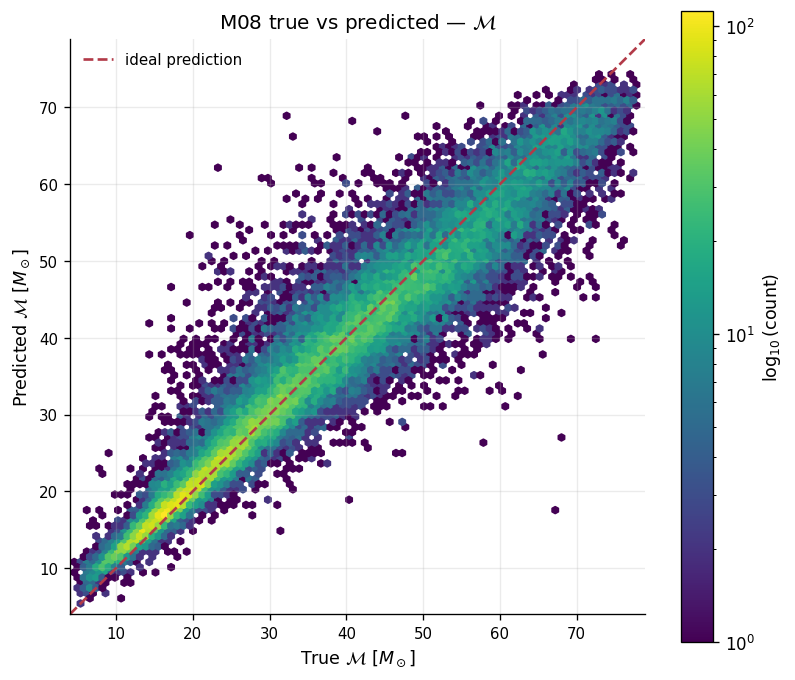

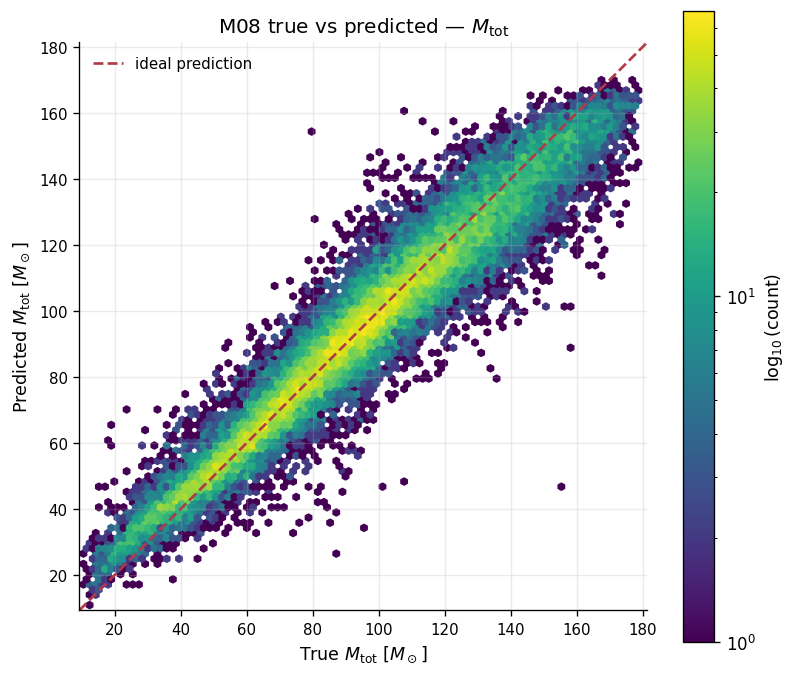

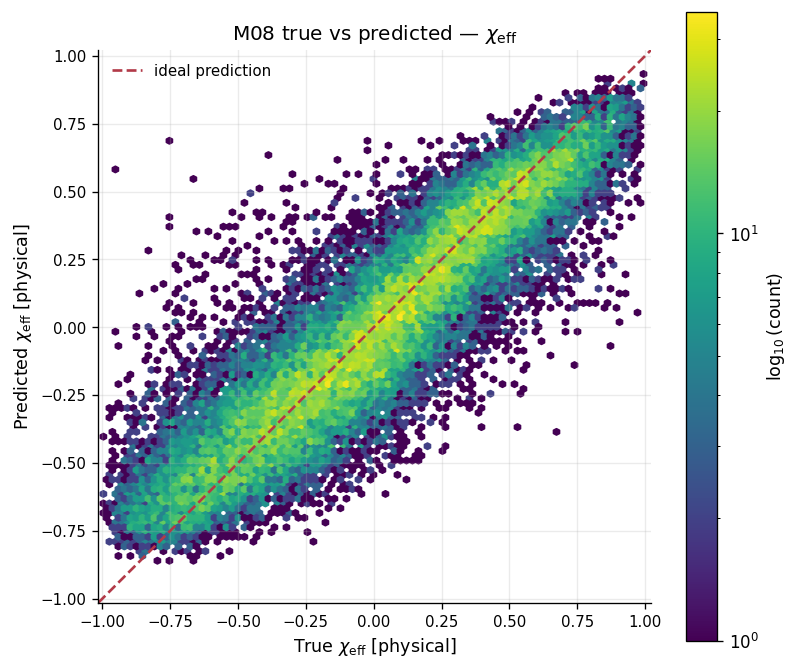

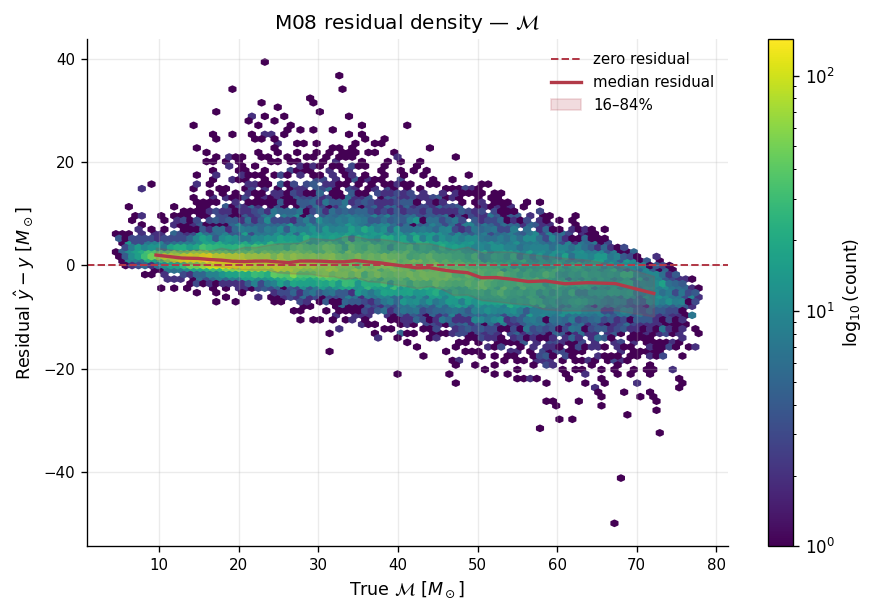

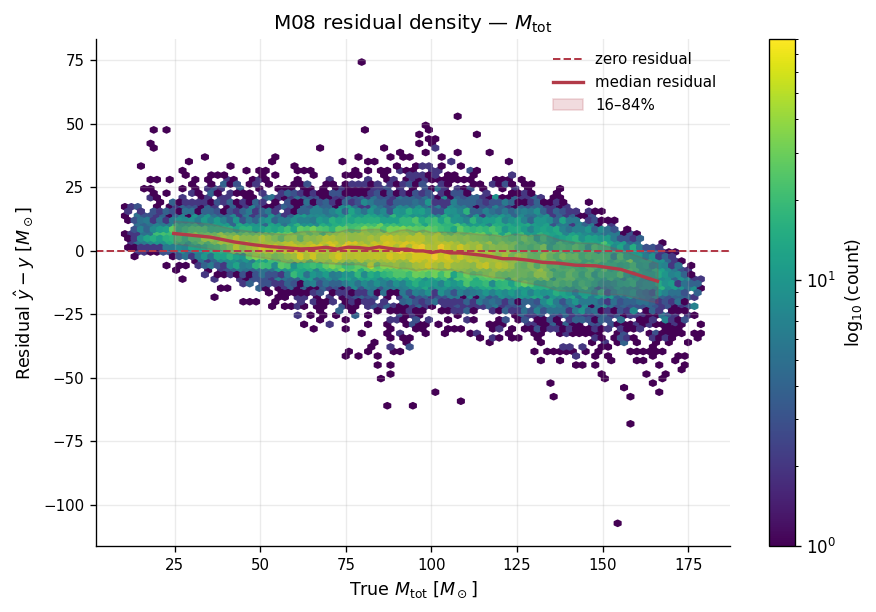

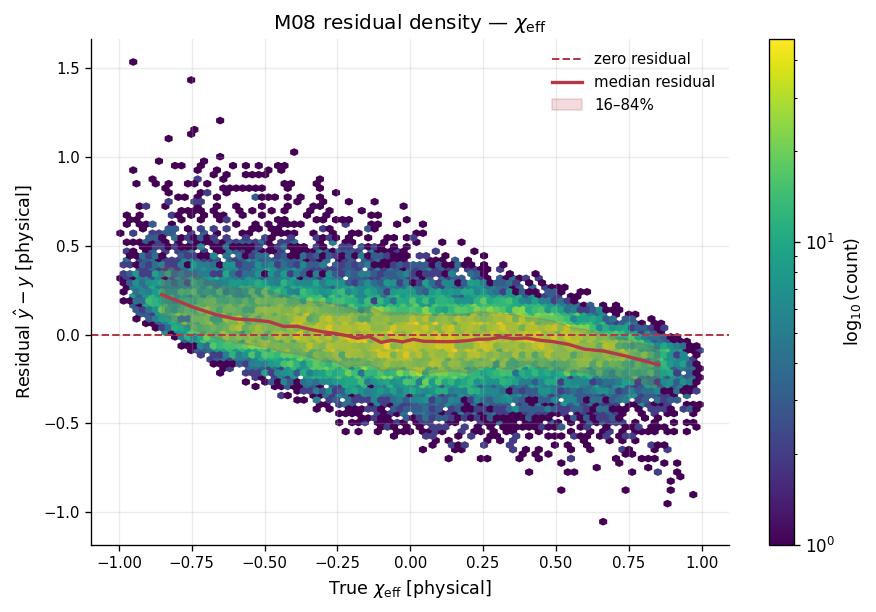

In [27]:
def plot_true_pred_density(split="test", physical_space=True, gridsize=90):
    data = SPLITS[split]

    if physical_space:
        y_true = inverse_standardize(data["y"])
        y_pred = inverse_standardize(data["pred"])
        space = "physical"
    else:
        y_true = data["y"]
        y_pred = data["pred"]
        space = "standardized"

    for j, label in enumerate(label_names):
        x = y_true[:, j]
        y = y_pred[:, j]

        lo = min(np.quantile(x, 0.001), np.quantile(y, 0.001))
        hi = max(np.quantile(x, 0.999), np.quantile(y, 0.999))
        pad = 0.03 * (hi - lo)
        lo -= pad
        hi += pad

        fig, ax = plt.subplots(figsize=(6.8, 5.9))

        hb = ax.hexbin(
            x,
            y,
            gridsize=gridsize,
            bins="log",
            mincnt=1,
            cmap=PALETTE["density_cmap"],
        )
        cbar = fig.colorbar(hb, ax=ax)
        cbar.set_label(r"$\log_{10}(\mathrm{count})$")

        ax.plot(
            [lo, hi],
            [lo, hi],
            linestyle="--",
            color=PALETTE["ideal"],
            linewidth=1.6,
            label="ideal prediction",
        )

        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect("equal", adjustable="box")

        if physical_space and label_unit(label):
            axis_label = f"{label_tex(label)} [{label_unit(label)}]"
        else:
            axis_label = f"{label_tex(label)} [{space}]"

        ax.set_xlabel(f"True {axis_label}")
        ax.set_ylabel(f"Predicted {axis_label}")
        ax.set_title(f"M08 true vs predicted — {label_tex(label)}")
        ax.legend(loc="upper left")
        style_axis(ax)

        plt.tight_layout()
        plt.show()


def plot_residual_density(split="test", physical_space=True, gridsize=90, trend_bins=35):
    data = SPLITS[split]

    if physical_space:
        y_true = inverse_standardize(data["y"])
        y_pred = inverse_standardize(data["pred"])
        space = "physical"
    else:
        y_true = data["y"]
        y_pred = data["pred"]
        space = "standardized"

    for j, label in enumerate(label_names):
        true = y_true[:, j]
        residual = y_pred[:, j] - y_true[:, j]

        fig, ax = plt.subplots(figsize=(7.6, 5.2))

        hb = ax.hexbin(
            true,
            residual,
            gridsize=gridsize,
            bins="log",
            mincnt=1,
            cmap=PALETTE["density_cmap"],
        )
        cbar = fig.colorbar(hb, ax=ax)
        cbar.set_label(r"$\log_{10}(\mathrm{count})$")

        ax.axhline(
            0.0,
            linestyle="--",
            color=PALETTE["ideal"],
            linewidth=1.2,
            label="zero residual",
        )

        edges = np.quantile(true, np.linspace(0, 1, trend_bins + 1))
        edges = np.unique(edges)

        centers = []
        medians = []
        q16 = []
        q84 = []

        for left, right in zip(edges[:-1], edges[1:]):
            mask = (true >= left) & (true <= right)
            if mask.sum() < 20:
                continue

            centers.append(np.median(true[mask]))
            medians.append(np.median(residual[mask]))
            q16.append(np.quantile(residual[mask], 0.16))
            q84.append(np.quantile(residual[mask], 0.84))

        centers = np.asarray(centers)
        medians = np.asarray(medians)
        q16 = np.asarray(q16)
        q84 = np.asarray(q84)

        ax.plot(
            centers,
            medians,
            linewidth=2.0,
            color=PALETTE["median"],
            label="median residual",
        )
        ax.fill_between(
            centers,
            q16,
            q84,
            color=PALETTE["median"],
            alpha=0.18,
            label="16–84%",
        )

        if physical_space and label_unit(label):
            x_label = f"True {label_tex(label)} [{label_unit(label)}]"
            y_label = f"Residual $\\hat y - y$ [{label_unit(label)}]"
        else:
            x_label = f"True {label_tex(label)} [{space}]"
            y_label = f"Residual $\\hat y - y$ [{space}]"

        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        ax.set_title(f"M08 residual density — {label_tex(label)}")
        ax.legend(loc="best")
        style_axis(ax)

        plt.tight_layout()
        plt.show()


plot_true_pred_density(split="test", physical_space=True)
plot_residual_density(split="test", physical_space=True)


## 6. Global split conformal baseline

This is not the final method, but it is the simplest conformal reference. It uses one residual quantile per label, without Mondrian bins.


In [6]:
def conformal_order_statistic(values, confidence_level):
    values = np.sort(np.asarray(values))
    n = len(values)
    k = int(np.ceil((n + 1) * confidence_level)) - 1
    k = int(np.clip(k, 0, n - 1))
    return values[k]


def global_symmetric_conformal(pred_cal, y_cal, pred_test, y_test, confidence_level):
    n_labels = y_cal.shape[1]
    lower = np.empty_like(pred_test)
    upper = np.empty_like(pred_test)
    quantiles = np.empty(n_labels)

    for j in range(n_labels):
        scores = np.abs(y_cal[:, j] - pred_cal[:, j])
        q = conformal_order_statistic(scores, confidence_level)
        quantiles[j] = q
        lower[:, j] = pred_test[:, j] - q
        upper[:, j] = pred_test[:, j] + q

    covered = (y_test >= lower) & (y_test <= upper)
    widths = upper - lower

    return {
        "lower": lower,
        "upper": upper,
        "quantiles": quantiles,
        "covered": covered,
        "widths": widths,
    }


GLOBAL_CONFORMAL = global_symmetric_conformal(
    pred_cal=SPLITS["cal"]["pred"],
    y_cal=SPLITS["cal"]["y"],
    pred_test=SPLITS["test"]["pred"],
    y_test=SPLITS["test"]["y"],
    confidence_level=CONFIDENCE_LEVEL,
)

global_rows = []
widths_phys = GLOBAL_CONFORMAL["widths"] * y_std

for j, label in enumerate(label_names):
    global_rows.append({
        "label": label,
        "coverage": float(GLOBAL_CONFORMAL["covered"][:, j].mean()),
        "mean_width_phys": float(np.mean(widths_phys[:, j])),
        "median_width_phys": float(np.median(widths_phys[:, j])),
        "q90_width_phys": float(np.quantile(widths_phys[:, j], 0.90)),
        "q95_width_phys": float(np.quantile(widths_phys[:, j], 0.95)),
        "score_quantile_std": float(GLOBAL_CONFORMAL["quantiles"][j]),
    })

global_conformal_df = pd.DataFrame(global_rows)
display(global_conformal_df)


,label,coverage,mean_width_phys,median_width_phys,q90_width_phys,q95_width_phys,score_quantile_std
0,chirp_mass,0.898100,15.935310,15.935310,15.935310,15.935310,0.483336
1,total_mass,0.900967,30.138083,30.138083,30.138083,30.138083,0.434891
2,chi_eff,0.899767,0.600533,0.600533,0.600533,0.600533,0.681100


## 7. Run M08 Mondrian grid

In [7]:
from src.conformal.pipeline import run_mondrian_regression

all_results = {}
summary_rows = []

pred_cal = SPLITS["cal"]["pred"]
y_cal = SPLITS["cal"]["y"]
emb_cal = SPLITS["cal"]["emb"]

pred_test = SPLITS["test"]["pred"]
y_test = SPLITS["test"]["y"]
emb_test = SPLITS["test"]["emb"]

for taxonomy_mode in TAXONOMY_MODES:
    for interval_mode in INTERVAL_MODES:
        for n_bins in N_BINS_GRID:
            kwargs = dict(
                pred_cal=pred_cal,
                pred_test=pred_test,
                y_cal=y_cal,
                y_test=y_test,
                n_bins=n_bins,
                confidence_level=CONFIDENCE_LEVEL,
                apply_jitter=True,
                interval_mode=interval_mode,
                taxonomy_mode=taxonomy_mode,
                min_samples_per_bin=MIN_SAMPLES_PER_BIN,
                tolerance_sigmas=(1, 2, 3),
            )

            if taxonomy_mode == "difficulty":
                kwargs.update(
                    cal_embedding=emb_cal,
                    target_embedding=emb_test,
                    n_neighbors=N_NEIGHBORS,
                )

            result = run_mondrian_regression(**kwargs)
            key = (taxonomy_mode, interval_mode, n_bins)
            all_results[key] = result

            metrics = result.metrics
            widths_std = result.upper - result.lower
            widths_phys = widths_std * y_std

            for j, label in enumerate(label_names):
                coverage_bin = metrics["coverage_per_bin"][:, j]
                count_bin = metrics["counts_per_bin"][:, j]
                valid_bins = count_bin > 0

                bin_tol = metrics["bin_tolerance_normal"]
                low_2s = bin_tol["2sigma_low"][:, j]
                high_2s = bin_tol["2sigma_high"][:, j]

                outside_2s = valid_bins & (
                    (coverage_bin < low_2s)
                    | (coverage_bin > high_2s)
                )
                under_2s = valid_bins & (coverage_bin < low_2s)
                over_2s = valid_bins & (coverage_bin > high_2s)

                covered = (
                    (result.lower[:, j] <= y_test[:, j])
                    & (y_test[:, j] <= result.upper[:, j])
                )

                lower_miss = y_test[:, j] < result.lower[:, j]
                upper_miss = y_test[:, j] > result.upper[:, j]

                lower_miss_rate = float(lower_miss.mean())
                upper_miss_rate = float(upper_miss.mean())

                summary_rows.append({
                    "taxonomy_mode": taxonomy_mode,
                    "interval_mode": interval_mode,
                    "n_bins": int(n_bins),
                    "label": label,
                    "label_index": j,

                    "global_coverage": float(metrics["global_coverage"][j]),
                    "global_miscoverage": float(1.0 - metrics["global_coverage"][j]),
                    "global_undercoverage_pvalue": float(metrics["global_undercoverage_pvalue"][j]),

                    "global_mean_width_std": float(np.mean(widths_std[:, j])),
                    "global_median_width_std": float(np.median(widths_std[:, j])),
                    "global_q90_width_std": float(np.quantile(widths_std[:, j], 0.90)),
                    "global_q95_width_std": float(np.quantile(widths_std[:, j], 0.95)),

                    "global_mean_width_phys": float(np.mean(widths_phys[:, j])),
                    "global_median_width_phys": float(np.median(widths_phys[:, j])),
                    "global_q90_width_phys": float(np.quantile(widths_phys[:, j], 0.90)),
                    "global_q95_width_phys": float(np.quantile(widths_phys[:, j], 0.95)),
                    "global_width_iqr_phys": float(
                        np.quantile(widths_phys[:, j], 0.75)
                        - np.quantile(widths_phys[:, j], 0.25)
                    ),

                    "min_coverage_per_bin": float(np.nanmin(coverage_bin[valid_bins])),
                    "max_coverage_per_bin": float(np.nanmax(coverage_bin[valid_bins])),
                    "max_undercoverage_gap": float(
                        np.nanmax(np.maximum(0.0, CONFIDENCE_LEVEL - coverage_bin[valid_bins]))
                    ),
                    "min_count_per_bin": int(np.nanmin(count_bin[valid_bins])),
                    "max_count_per_bin": int(np.nanmax(count_bin[valid_bins])),

                    "n_bins_outside_2sigma": int(outside_2s.sum()),
                    "outside_bin_fraction_2sigma": float(outside_2s.sum() / valid_bins.sum()),
                    "n_bins_under_2sigma": int(under_2s.sum()),
                    "under_bin_fraction_2sigma": float(under_2s.sum() / valid_bins.sum()),
                    "n_bins_over_2sigma": int(over_2s.sum()),
                    "over_bin_fraction_2sigma": float(over_2s.sum() / valid_bins.sum()),

                    "min_bin_2sigma_low": float(np.nanmin(low_2s[valid_bins])),
                    "max_bin_2sigma_high": float(np.nanmax(high_2s[valid_bins])),

                    "lower_miss_rate": lower_miss_rate,
                    "upper_miss_rate": upper_miss_rate,
                    "global_tail_miss_imbalance": float(abs(lower_miss_rate - upper_miss_rate)),

                    "global_1sigma_low": float(metrics["global_tolerance_normal"]["1sigma_low"][j]),
                    "global_1sigma_high": float(metrics["global_tolerance_normal"]["1sigma_high"][j]),
                    "global_2sigma_low": float(metrics["global_tolerance_normal"]["2sigma_low"][j]),
                    "global_2sigma_high": float(metrics["global_tolerance_normal"]["2sigma_high"][j]),
                    "global_3sigma_low": float(metrics["global_tolerance_normal"]["3sigma_low"][j]),
                    "global_3sigma_high": float(metrics["global_tolerance_normal"]["3sigma_high"][j]),
                    "global_within_2sigma": bool(
                        (metrics["global_coverage"][j] >= metrics["global_tolerance_normal"]["2sigma_low"][j])
                        and (metrics["global_coverage"][j] <= metrics["global_tolerance_normal"]["2sigma_high"][j])
                    ),
                })

summary_df = pd.DataFrame(summary_rows)

display(summary_df.head())
print("Number of evaluated configurations:", len(summary_df))


,taxonomy_mode,interval_mode,n_bins,label,label_index,global_coverage,global_miscoverage,global_undercoverage_pvalue,global_mean_width_std,global_median_width_std,global_q90_width_std,global_q95_width_std,global_mean_width_phys,global_median_width_phys,global_q90_width_phys,global_q95_width_phys,global_width_iqr_phys,min_coverage_per_bin,max_coverage_per_bin,max_undercoverage_gap,min_count_per_bin,max_count_per_bin,n_bins_outside_2sigma,outside_bin_fraction_2sigma,n_bins_under_2sigma,under_bin_fraction_2sigma,n_bins_over_2sigma,over_bin_fraction_2sigma,min_bin_2sigma_low,max_bin_2sigma_high,lower_miss_rate,upper_miss_rate,global_tail_miss_imbalance,global_1sigma_low,global_1sigma_high,global_2sigma_low,global_2sigma_high,global_3sigma_low,global_3sigma_high,global_within_2sigma
0,prediction,symmetric,4,chirp_mass,0,0.902100,0.097900,0.889401,0.916320,1.193787,1.217017,1.217017,15.105285,19.679241,20.062194,20.062194,12.966920,0.896654,0.906690,0.003346,7383,7609,0,0.000000,0,0.000000,0,0.000000,0.893017,0.906983,0.053967,0.043933,0.010033,0.898268,0.901732,0.896536,0.903464,0.894804,0.905196,True
1,prediction,symmetric,4,total_mass,1,0.901400,0.098600,0.793055,0.852865,0.923775,1.050597,1.050597,29.551911,32.008953,36.403350,36.403350,8.592998,0.896088,0.905715,0.003912,7410,7594,0,0.000000,0,0.000000,0,0.000000,0.893030,0.906970,0.042367,0.056233,0.013867,0.898268,0.901732,0.896536,0.903464,0.894804,0.905196,True
2,prediction,symmetric,4,chi_eff,2,0.900233,0.099767,0.556390,1.360168,1.380557,1.489133,1.489133,0.599637,0.608626,0.656492,0.656492,0.090169,0.890816,0.909545,0.009184,7383,7611,2,0.500000,1,0.250000,1,0.250000,0.893017,0.906983,0.051533,0.048233,0.003300,0.898268,0.901732,0.896536,0.903464,0.894804,0.905196,True
3,prediction,symmetric,6,chirp_mass,0,0.902200,0.097800,0.899984,0.913780,1.129274,1.307074,1.307074,15.063416,18.615762,21.546745,21.546745,9.592974,0.898551,0.906897,0.001449,4955,5037,0,0.000000,0,0.000000,0,0.000000,0.891476,0.908524,0.054967,0.042833,0.012133,0.898268,0.901732,0.896536,0.903464,0.894804,0.905196,True
4,prediction,symmetric,6,total_mass,1,0.901867,0.098133,0.861664,0.854665,0.877651,1.044895,1.044895,29.614289,30.410741,36.205795,36.205795,10.266049,0.895689,0.909435,0.004311,4918,5054,1,0.166667,0,0.000000,1,0.166667,0.891444,0.908556,0.042733,0.055400,0.012667,0.898268,0.901732,0.896536,0.903464,0.894804,0.905196,True


Number of evaluated configurations: 96


## 8. Grid overview

In [8]:
overview_cols = [
    "taxonomy_mode",
    "interval_mode",
    "n_bins",
    "label",
    "global_coverage",
    "min_coverage_per_bin",
    "n_bins_under_2sigma",
    "under_bin_fraction_2sigma",
    "max_undercoverage_gap",
    "global_median_width_phys",
    "global_q95_width_phys",
    "global_tail_miss_imbalance",
    "min_count_per_bin",
]

display(
    summary_df[overview_cols]
    .sort_values(["label", "global_median_width_phys"])
    .head(30)
)

grid_agg_df = (
    summary_df
    .groupby(["taxonomy_mode", "interval_mode", "label"], as_index=False)
    .agg(
        n_configs=("n_bins", "count"),
        median_coverage=("global_coverage", "median"),
        median_width_phys=("global_median_width_phys", "median"),
        min_width_phys=("global_median_width_phys", "min"),
        median_under_bins=("n_bins_under_2sigma", "median"),
        median_max_undercoverage_gap=("max_undercoverage_gap", "median"),
        median_tail_imbalance=("global_tail_miss_imbalance", "median"),
    )
)

display(grid_agg_df)


,taxonomy_mode,interval_mode,n_bins,label,global_coverage,min_coverage_per_bin,n_bins_under_2sigma,under_bin_fraction_2sigma,max_undercoverage_gap,global_median_width_phys,global_q95_width_phys,global_tail_miss_imbalance,min_count_per_bin
59,difficulty,symmetric,12,chi_eff,0.899067,0.882232,1,0.083333,0.017768,0.561315,0.894796,0.002133,2401
83,difficulty,asymmetric,12,chi_eff,0.898367,0.881822,2,0.166667,0.018178,0.561506,0.896711,0.001233,2401
86,difficulty,asymmetric,16,chi_eff,0.897667,0.871574,3,0.187500,0.028426,0.567800,0.942895,0.002467,1715
62,difficulty,symmetric,16,chi_eff,0.898733,0.875873,2,0.125000,0.024127,0.568400,0.949893,0.001800,1715
71,difficulty,symmetric,48,chi_eff,0.899267,0.855285,7,0.145833,0.044715,0.568635,0.784408,0.001867,540
80,difficulty,asymmetric,8,chi_eff,0.897933,0.884282,2,0.250000,0.015718,0.569576,0.844779,0.001467,3576
56,difficulty,symmetric,8,chi_eff,0.897733,0.882114,2,0.250000,0.017886,0.569821,0.843345,0.002600,3576
65,difficulty,symmetric,24,chi_eff,0.898600,0.864992,3,0.125000,0.035008,0.572151,0.764237,0.002000,1163
95,difficulty,asymmetric,48,chi_eff,0.897300,0.850407,7,0.145833,0.049593,0.574221,0.778364,0.001633,540
89,difficulty,asymmetric,24,chi_eff,0.898800,0.864992,4,0.166667,0.035008,0.575170,0.765311,0.000800,1163


,taxonomy_mode,interval_mode,label,n_configs,median_coverage,median_width_phys,min_width_phys,median_under_bins,median_max_undercoverage_gap,median_tail_imbalance
0,difficulty,asymmetric,chi_eff,8,0.898100,0.574695,0.561506,2.500000,0.023302,0.001450
1,difficulty,asymmetric,chirp_mass,8,0.901133,14.792631,14.483780,1.000000,0.018919,0.001517
2,difficulty,asymmetric,total_mass,8,0.901817,29.119378,28.026046,0.000000,0.010585,0.001167
3,difficulty,symmetric,chi_eff,8,0.898667,0.570986,0.561315,2.000000,0.021006,0.002100
4,difficulty,symmetric,chirp_mass,8,0.901550,14.777594,14.356512,1.000000,0.019073,0.001650
5,difficulty,symmetric,total_mass,8,0.901683,29.013322,28.443543,1.000000,0.014886,0.023200
6,prediction,asymmetric,chi_eff,8,0.899867,0.620618,0.605323,2.000000,0.018772,0.001067
7,prediction,asymmetric,chirp_mass,8,0.902717,16.948277,15.093020,0.000000,0.010695,0.000283
8,prediction,asymmetric,total_mass,8,0.901167,28.175716,27.286712,0.000000,0.011997,0.002117
9,prediction,symmetric,chi_eff,8,0.900667,0.619858,0.602634,1.500000,0.017976,0.002717


## 9. Configuration selection policy

In [9]:
MIN_COUNT_PER_BIN = 200
WIDTH_TIE_FRACTION = 0.02
MAX_UNDER_BIN_FRACTION_EFFICIENT = 0.10
MAX_UNDERCOVERAGE_GAP_EFFICIENT = 0.05
TOP_K = 8


def get_base_candidates(model_summary, label):
    return model_summary[
        (model_summary["label"] == label)
        & model_summary["global_within_2sigma"]
        & (model_summary["min_count_per_bin"] >= MIN_COUNT_PER_BIN)
    ].copy()


def select_conservative(model_summary, label):
    candidates = get_base_candidates(model_summary, label)

    if candidates.empty:
        raise ValueError(f"No globally valid candidates for label={label}")

    zero_under = candidates[candidates["n_bins_under_2sigma"] == 0].copy()

    if not zero_under.empty:
        pool = zero_under
        policy = "conservative_zero_under_bins_2sigma"
    else:
        min_under = candidates["n_bins_under_2sigma"].min()
        pool = candidates[candidates["n_bins_under_2sigma"] == min_under].copy()
        policy = "conservative_best_available"

    min_width = pool["global_median_width_phys"].min()
    width_limit = min_width * (1 + WIDTH_TIE_FRACTION)

    tied = pool[pool["global_median_width_phys"] <= width_limit].copy()
    tied["min_width_for_label"] = min_width
    tied["width_limit"] = width_limit
    tied["relative_width_excess"] = tied["global_median_width_phys"] / min_width - 1

    ranked = tied.sort_values(
        [
            "n_bins",
            "max_undercoverage_gap",
            "global_tail_miss_imbalance",
            "global_median_width_phys",
        ],
        ascending=[False, True, True, True],
    )

    selected = ranked.iloc[0].copy()
    selected["selection_policy"] = policy
    return selected, ranked


def select_efficient(model_summary, label):
    candidates = get_base_candidates(model_summary, label)

    candidates = candidates[
        (candidates["under_bin_fraction_2sigma"] <= MAX_UNDER_BIN_FRACTION_EFFICIENT)
        & (candidates["max_undercoverage_gap"] <= MAX_UNDERCOVERAGE_GAP_EFFICIENT)
    ].copy()

    if candidates.empty:
        return select_conservative(model_summary, label)

    min_width = candidates["global_median_width_phys"].min()
    width_limit = min_width * (1 + WIDTH_TIE_FRACTION)

    tied = candidates[candidates["global_median_width_phys"] <= width_limit].copy()
    tied["min_width_for_label"] = min_width
    tied["width_limit"] = width_limit
    tied["relative_width_excess"] = tied["global_median_width_phys"] / min_width - 1

    ranked = tied.sort_values(
        [
            "global_median_width_phys",
            "n_bins_under_2sigma",
            "max_undercoverage_gap",
            "global_tail_miss_imbalance",
            "n_bins",
        ],
        ascending=[True, True, True, True, False],
    )

    selected = ranked.iloc[0].copy()
    selected["selection_policy"] = "efficient_local_validity_tolerant"
    return selected, ranked


selection_rows = []
top_rows = []

for label in label_names:
    conservative, conservative_ranked = select_conservative(summary_df, label)
    efficient, efficient_ranked = select_efficient(summary_df, label)

    conservative_dict = conservative.to_dict()
    conservative_dict["final_policy"] = "conservative"
    selection_rows.append(conservative_dict)

    efficient_dict = efficient.to_dict()
    efficient_dict["final_policy"] = "efficient"
    selection_rows.append(efficient_dict)

    top_rows.append(
        conservative_ranked
        .head(TOP_K)
        .assign(label=label, final_policy="conservative")
    )
    top_rows.append(
        efficient_ranked
        .head(TOP_K)
        .assign(label=label, final_policy="efficient")
    )

selection_df = pd.DataFrame(selection_rows)
top_candidates_df = pd.concat(top_rows, ignore_index=True)

selection_display_cols = [
    "final_policy",
    "label",
    "selection_policy",
    "taxonomy_mode",
    "interval_mode",
    "n_bins",
    "global_coverage",
    "min_coverage_per_bin",
    "n_bins_under_2sigma",
    "under_bin_fraction_2sigma",
    "max_undercoverage_gap",
    "global_median_width_phys",
    "global_q90_width_phys",
    "global_q95_width_phys",
    "global_tail_miss_imbalance",
    "min_count_per_bin",
]

display(
    selection_df[selection_display_cols]
    .sort_values(["label", "final_policy"])
)


,final_policy,label,selection_policy,taxonomy_mode,interval_mode,n_bins,global_coverage,min_coverage_per_bin,n_bins_under_2sigma,under_bin_fraction_2sigma,max_undercoverage_gap,global_median_width_phys,global_q90_width_phys,global_q95_width_phys,global_tail_miss_imbalance,min_count_per_bin
4,conservative,chi_eff,conservative_zero_under_bins_2sigma,difficulty,symmetric,6,0.898400,0.892167,0,0.000000,0.007833,0.576291,0.812271,0.812271,0.002067,4915
5,efficient,chi_eff,efficient_local_validity_tolerant,difficulty,symmetric,12,0.899067,0.882232,1,0.083333,0.017768,0.561315,0.721185,0.894796,0.002133,2401
0,conservative,chirp_mass,conservative_zero_under_bins_2sigma,prediction,asymmetric,24,0.902767,0.886381,0,0.000000,0.013619,15.623656,21.191378,21.730857,0.000233,1170
1,efficient,chirp_mass,efficient_local_validity_tolerant,difficulty,symmetric,24,0.901567,0.873544,1,0.041667,0.026456,14.356512,23.366214,24.942036,0.002367,1150
2,conservative,total_mass,conservative_zero_under_bins_2sigma,prediction,asymmetric,16,0.901067,0.887652,0,0.000000,0.012348,27.919006,37.565449,38.805998,0.001933,1792
3,efficient,total_mass,efficient_local_validity_tolerant,prediction,asymmetric,32,0.901500,0.874737,2,0.062500,0.025263,27.286712,37.805153,38.552800,0.001833,853


## 10. Selected-configuration visual diagnostics

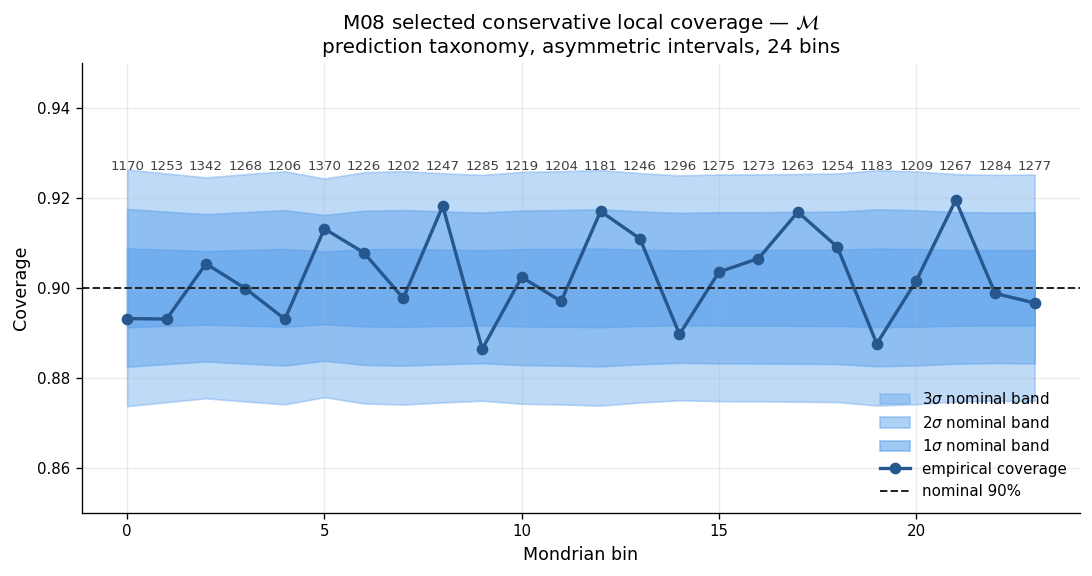

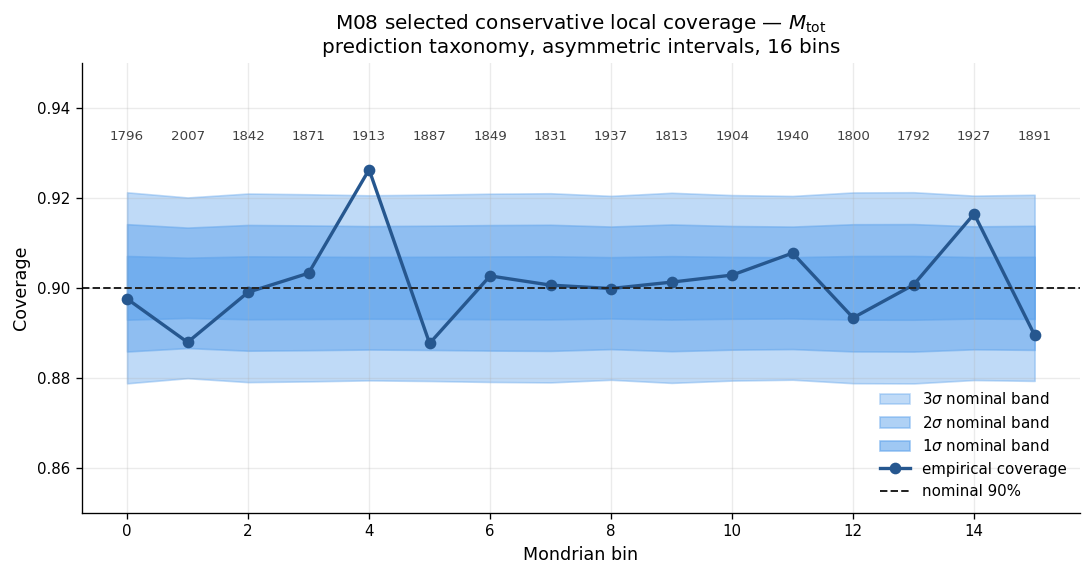

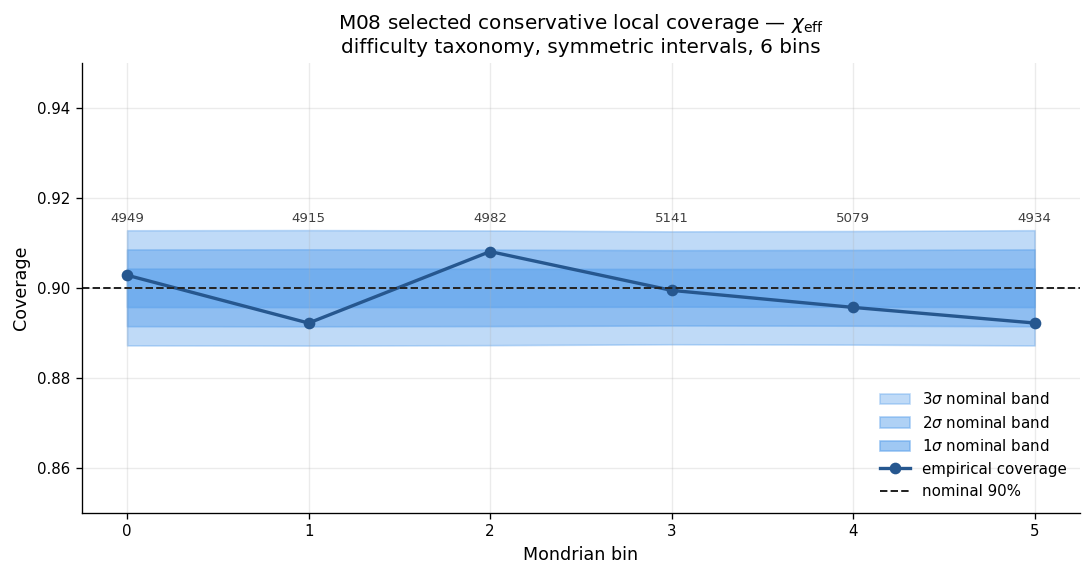

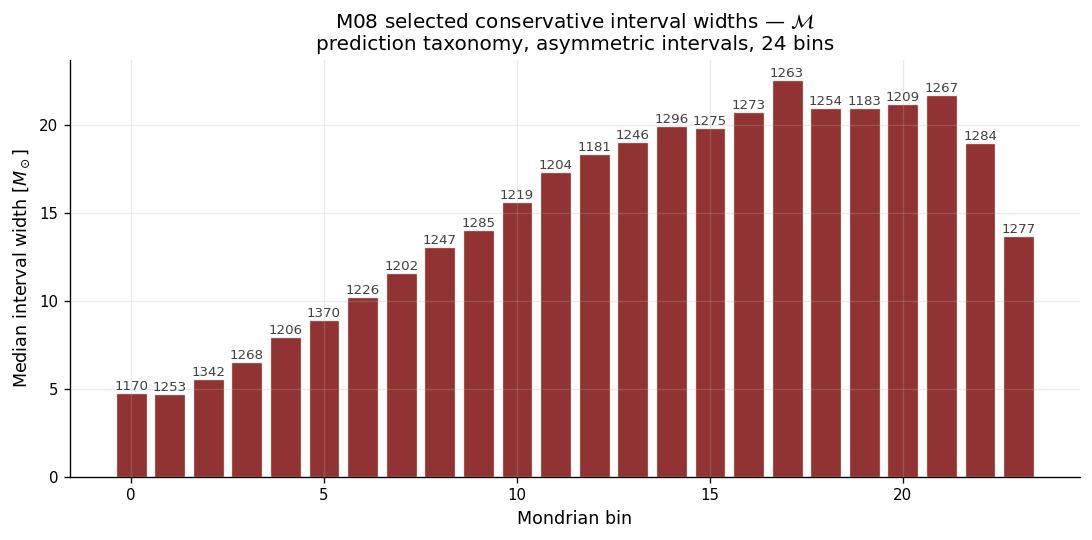

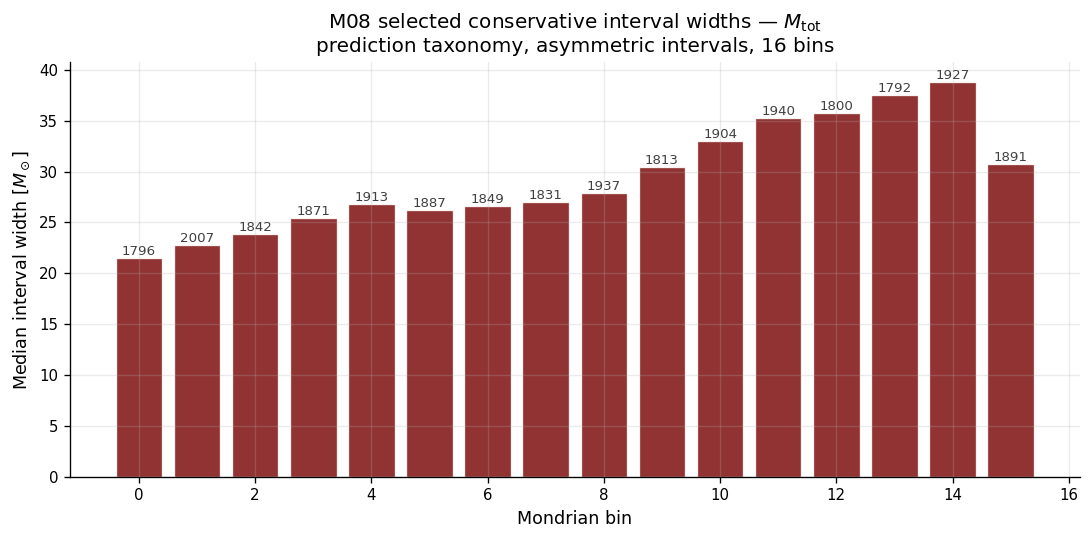

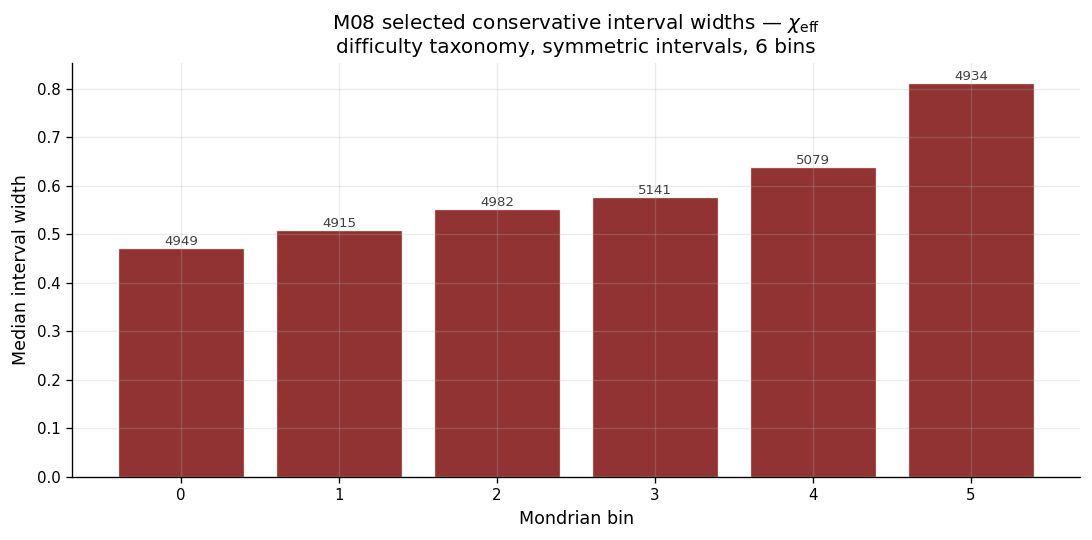

In [52]:
def get_selected_result(label, final_policy="conservative"):
    row = selection_df[
        (selection_df["label"] == label)
        & (selection_df["final_policy"] == final_policy)
    ].iloc[0]

    key = (
        row["taxonomy_mode"],
        row["interval_mode"],
        int(row["n_bins"]),
    )

    return row, all_results[key]


def plot_selected_bin_coverage(final_policy="conservative"):
    for label in label_names:
        label_idx = label_names.index(label)
        row, result = get_selected_result(label, final_policy=final_policy)
        metrics = result.metrics

        coverage = metrics["coverage_per_bin"][:, label_idx]
        counts = metrics["counts_per_bin"][:, label_idx]

        low_1s = metrics["bin_tolerance_normal"]["1sigma_low"][:, label_idx]
        high_1s = metrics["bin_tolerance_normal"]["1sigma_high"][:, label_idx]

        low_2s = metrics["bin_tolerance_normal"]["2sigma_low"][:, label_idx]
        high_2s = metrics["bin_tolerance_normal"]["2sigma_high"][:, label_idx]

        low_3s = metrics["bin_tolerance_normal"]["3sigma_low"][:, label_idx]
        high_3s = metrics["bin_tolerance_normal"]["3sigma_high"][:, label_idx]


        x = np.arange(len(coverage))

        fig, ax = plt.subplots(figsize=(9.2, 4.9))

        ax.fill_between(
            x,
            low_3s,
            high_3s,
            color=PALETTE["band_3"],
            alpha=0.40,
            label=r"$3\sigma$ nominal band",
        )

        ax.fill_between(
            x,
            low_2s,
            high_2s,
            color=PALETTE["band_2"],
            alpha=0.50,
            label=r"$2\sigma$ nominal band",
        )

        ax.fill_between(
            x,
            low_1s,
            high_1s,
            color=PALETTE["band_1"],
            alpha=0.60,
            label=r"$1\sigma$ nominal band",
        )
        ax.plot(
            x,
            coverage,
            marker="o",
            linewidth=2.0,
            color=PALETTE["coverage"],
            label="empirical coverage",
        )
        ax.axhline(
            CONFIDENCE_LEVEL,
            linestyle="--",
            color=PALETTE["nominal"],
            linewidth=1.2,
            label="nominal 90%",
        )

        for xi, n in zip(x, counts):
            ax.text(
                xi,
                min(0.995, max(coverage) + 0.006),
                f"{int(n)}",
                ha="center",
                va="bottom",
                fontsize=8,
                color="0.25",
            )

        ax.set_xlabel("Mondrian bin")
        ax.set_ylabel("Coverage")
        ax.set_title(
            f"M08 selected {final_policy} local coverage — {label_tex(label)}\n"
            f"{row['taxonomy_mode']} taxonomy, {row['interval_mode']} intervals, {int(row['n_bins'])} bins"
        )
        ax.set_ylim(0.85, 0.95)
        ax.legend(loc="lower right")
        style_axis(ax)

        plt.tight_layout()
        plt.show()


def plot_selected_bin_widths(final_policy="conservative"):
    for label in label_names:
        label_idx = label_names.index(label)
        row, result = get_selected_result(label, final_policy=final_policy)

        widths_phys = (result.upper - result.lower)[:, label_idx] * y_std[label_idx]
        bins = result.bin_indices_test[:, label_idx]

        width_by_bin = []
        counts = []

        for b in range(int(row["n_bins"])):
            mask = bins == b
            counts.append(mask.sum())
            width_by_bin.append(np.median(widths_phys[mask]) if mask.any() else np.nan)

        x = np.arange(int(row["n_bins"]))

        fig, ax = plt.subplots(figsize=(9.2, 4.6))
        ax.bar(
            x,
            width_by_bin,
            color=PALETTE["width"],
            alpha=0.88,
            edgecolor="white",
            linewidth=0.8,
        )

        ax.set_xlabel("Mondrian bin")

        unit = label_unit(label)
        ylabel = f"Median interval width [{unit}]" if unit else "Median interval width"
        ax.set_ylabel(ylabel)

        ax.set_title(
            f"M08 selected {final_policy} interval widths — {label_tex(label)}\n"
            f"{row['taxonomy_mode']} taxonomy, {row['interval_mode']} intervals, {int(row['n_bins'])} bins"
        )

        for xi, (w, n) in enumerate(zip(width_by_bin, counts)):
            if np.isfinite(w):
                ax.text(
                    xi,
                    w,
                    f"{int(n)}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    color="0.25",
                    rotation=0,
                )

        style_axis(ax)
        plt.tight_layout()
        plt.show()


plot_selected_bin_coverage(final_policy="conservative")
plot_selected_bin_widths(final_policy="conservative")



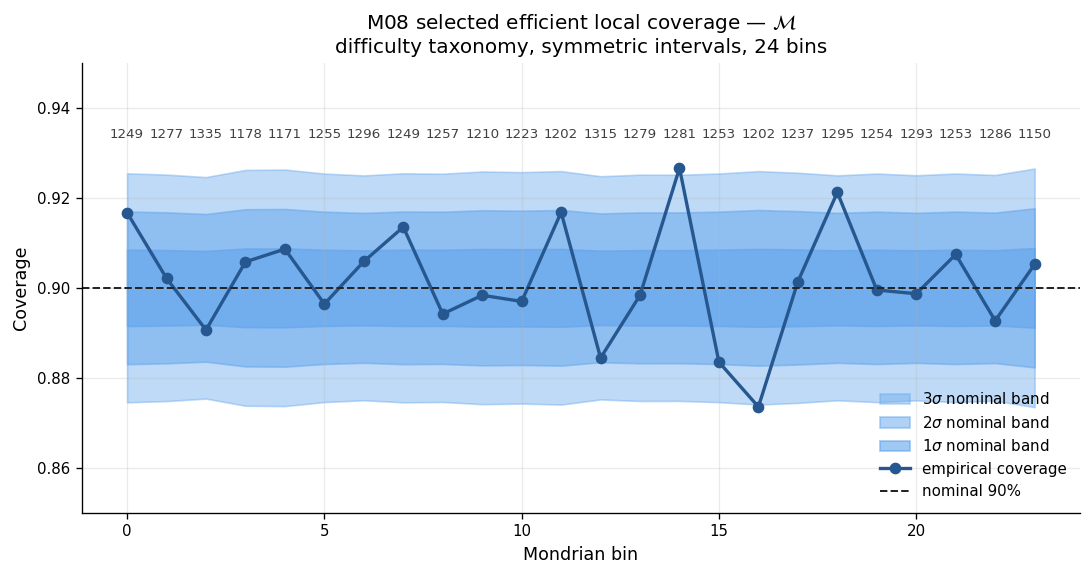

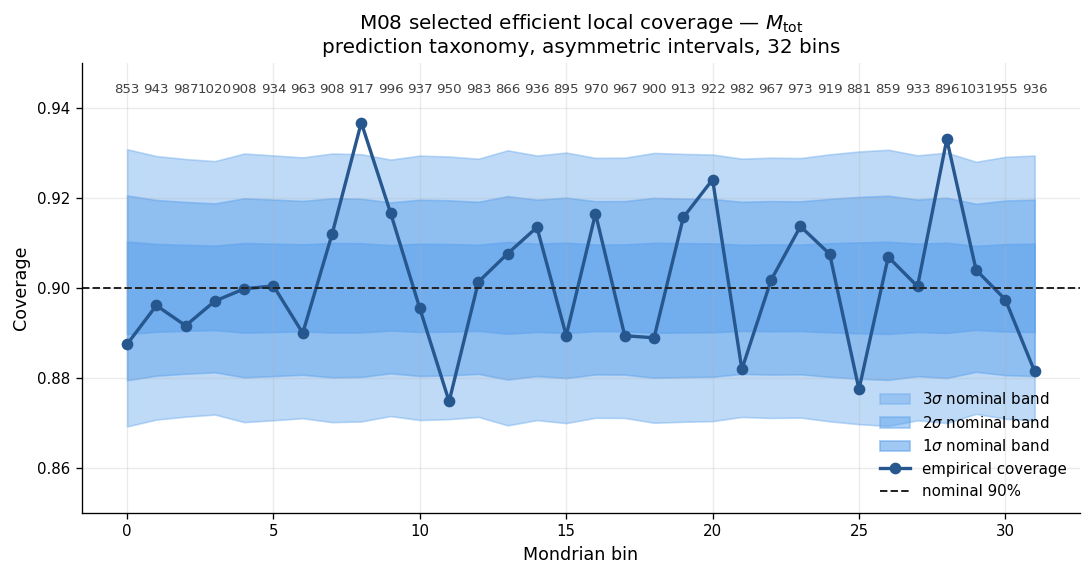

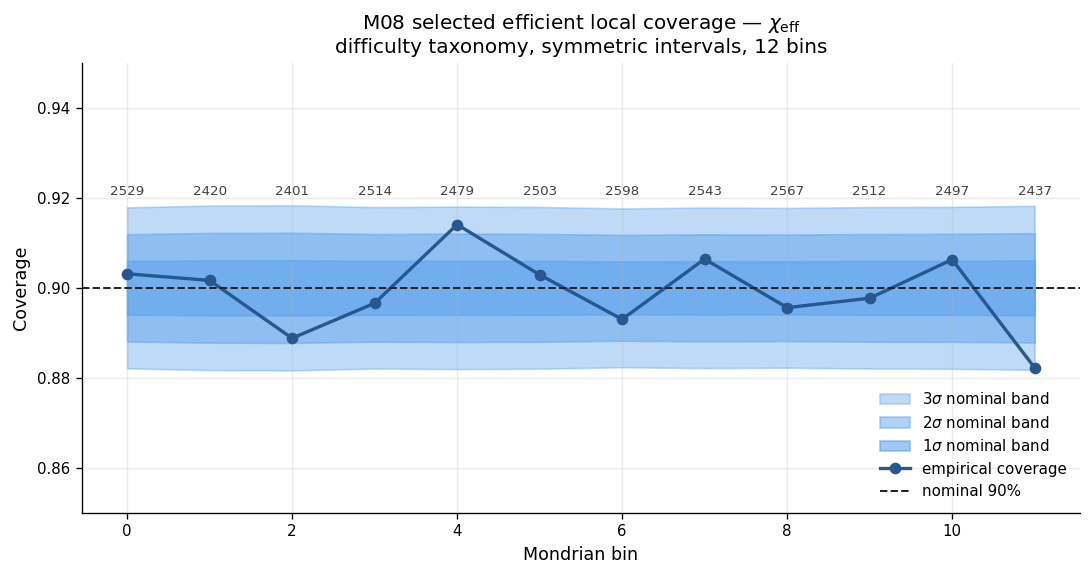

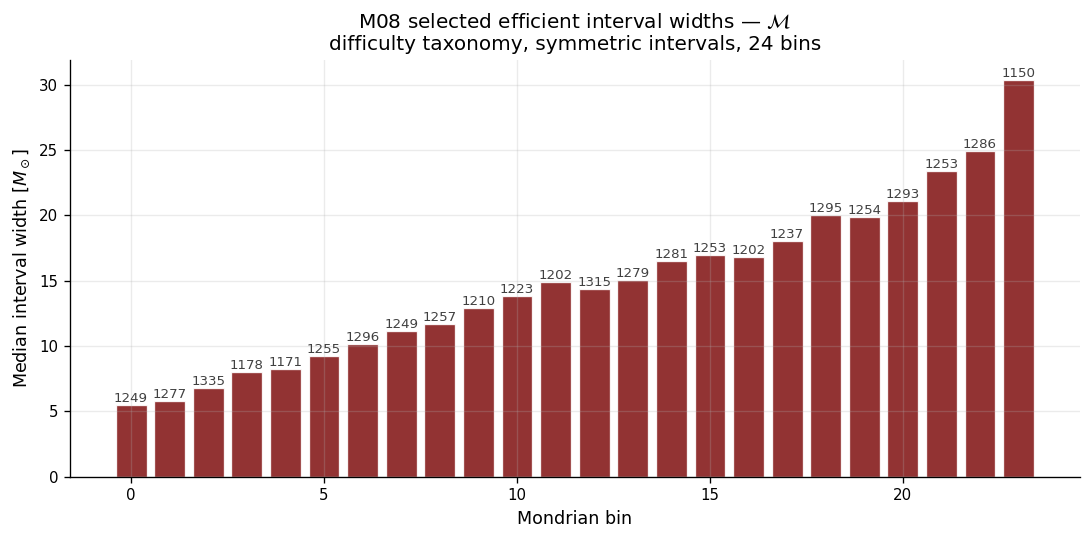

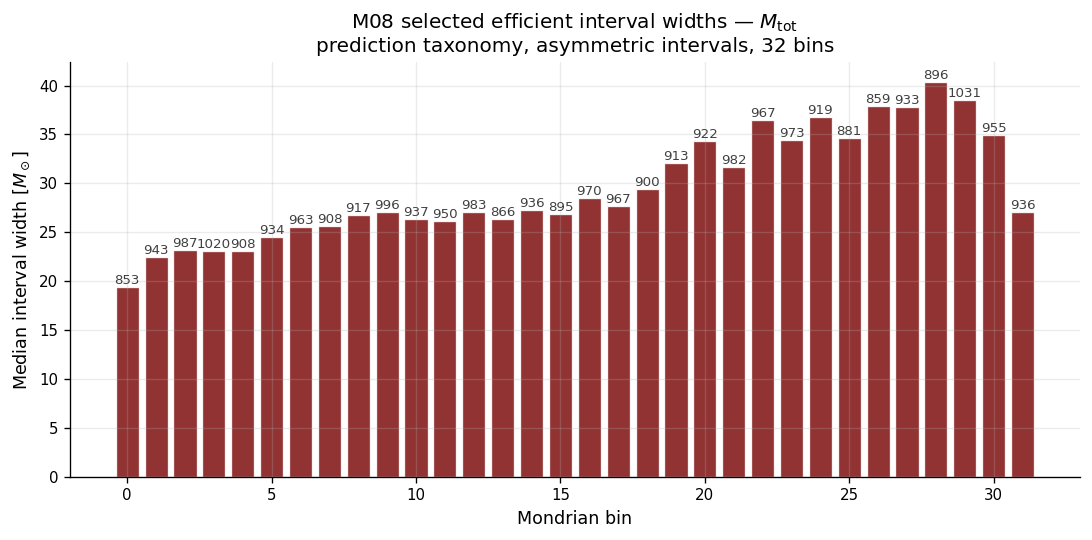

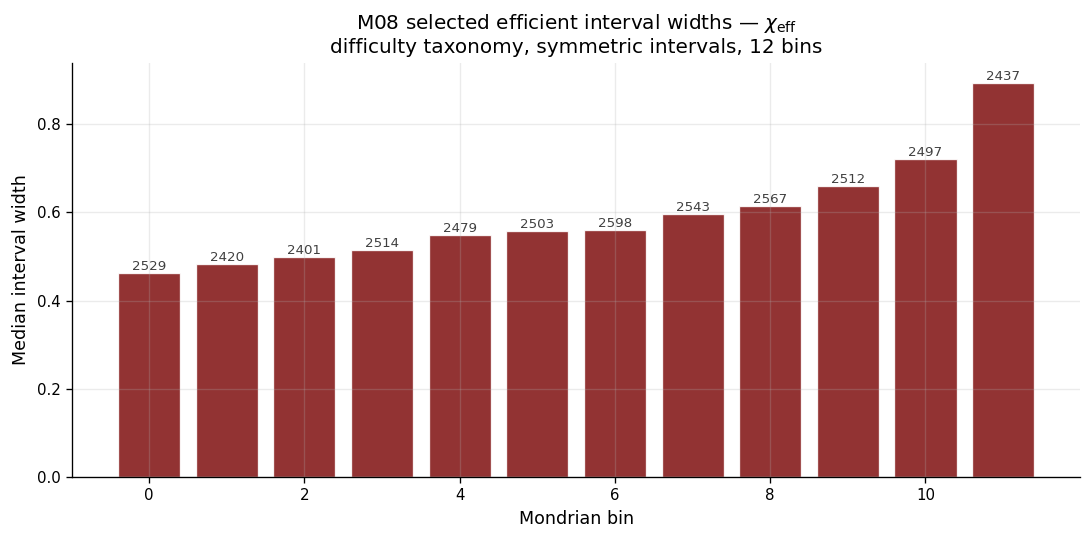

In [53]:
plot_selected_bin_coverage(final_policy="efficient")
plot_selected_bin_widths(final_policy="efficient")

## 11. Conditional diagnostics from HDF5 metadata

This section loads event-level metadata from the HDF5 dataset and uses it to test whether the selected conformal intervals behave uniformly across physically meaningful regions.

The idea is simple:

1. choose a conditioning variable, for example network SNR or true total mass;
2. split the test set into quantile bins of that variable;
3. compute, inside each bin:
   - empirical coverage;
   - median interval width;
   - number of test events.

This is not a new conformal calibration step. It is a **diagnostic**. It asks whether the final selected intervals remain trustworthy in regions such as low SNR, high mass, long signals, or extreme spin.

The most important plots are therefore not only global coverage plots, but conditional coverage/width curves as a function of:

- network SNR, $\rho_{\mathrm{net}}$;
- effective signal duration, $\Delta t_{\mathrm{GW}}$;
- true chirp mass, $\mathcal{M}$;
- true total mass, $M_{\mathrm{tot}}$;
- true effective spin, $\chi_{\mathrm{eff}}$.


In [11]:
import h5py

def read_hdf5_dataset_preserve_order(h5_file, dataset_key, indices, dtype=None):
    indices = np.asarray(indices, dtype=np.int64)
    order = np.argsort(indices, kind="stable")
    sorted_indices = indices[order]

    values_sorted = np.asarray(h5_file[dataset_key][sorted_indices], dtype=dtype)

    inverse_order = np.empty_like(order)
    inverse_order[order] = np.arange(len(order))

    return values_sorted[inverse_order]


def hdf5_key_exists(path):
    with h5py.File(DATASET_H5_PATH, "r") as f:
        return path in f


def load_test_metadata_fields():
    candidate_fields = {
        "network_snr": "snr/network",
        "target_snr": "snr/target_network",
        "mass_1": "parameters/mass_1",
        "mass_2": "parameters/mass_2",
        "chirp_mass": "parameters/chirp_mass",
        "total_mass": "parameters/total_mass",
        "chi_eff": "parameters/chi_eff",
        "distance": "parameters/distance",
        "signal_network_duration": "placement/signal_network_duration",
        "margin_before_signal": "placement/margin_before_signal",
        "margin_after_signal": "placement/margin_after_signal",
    }

    idx = SPLITS["test"]["idx"]
    out = {"hdf5_index": idx}

    with h5py.File(DATASET_H5_PATH, "r") as f:
        for name, key in candidate_fields.items():
            if key in f:
                out[name] = read_hdf5_dataset_preserve_order(f, key, idx)
            else:
                print(f"Missing HDF5 field: {key}")

    return pd.DataFrame(out)


test_meta_df = load_test_metadata_fields()
display(test_meta_df.head())
display(test_meta_df.describe())


,hdf5_index,network_snr,target_snr,mass_1,mass_2,chirp_mass,total_mass,chi_eff,distance,signal_network_duration,margin_before_signal,margin_after_signal
0,10,18.229866,18.229866,63.884521,19.921326,30.072771,83.805847,0.240261,645.598511,0.398438,1.192003,2.409559
1,13,23.198574,23.198574,83.756020,66.471252,64.869446,150.227280,0.488239,2586.593994,0.421143,2.423045,1.155812
2,18,19.833614,19.833614,82.492447,7.385210,19.060570,89.877655,-0.884607,296.434601,0.251221,3.748606,0.000173
3,23,13.214932,13.214932,42.749413,26.913490,29.372425,69.662903,0.015606,2883.240234,0.361816,3.456671,0.181513
4,35,19.602468,19.602468,27.067228,20.961945,20.702566,48.029175,-0.720734,903.000427,0.424561,0.745086,2.830354


,hdf5_index,network_snr,target_snr,mass_1,mass_2,chirp_mass,total_mass,chi_eff,distance,signal_network_duration,margin_before_signal,margin_after_signal
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,249174.097367,16.893896,16.893896,61.713757,33.422291,37.516865,95.136040,0.004608,1706.417358,0.466294,1.771812,1.761894
std,144425.042572,4.346852,4.346852,19.970306,20.088476,16.532505,34.679493,0.440329,1181.676880,0.325068,1.035134,1.036171
min,10.000000,10.000003,10.000003,5.472352,5.000877,4.573939,10.519637,-0.995358,49.751011,0.244629,0.000000,0.000000
25%,123029.500000,13.073044,13.073044,47.397392,16.362895,23.852234,70.192976,-0.333339,820.530624,0.326416,0.876539,0.861497
50%,249600.000000,16.568607,16.568607,65.203869,30.075184,36.254585,95.292068,0.010066,1396.183655,0.371338,1.749381,1.751185
75%,374350.500000,20.613446,20.613446,78.594152,47.589226,50.057863,119.994854,0.343426,2298.970032,0.452393,2.660816,2.647854
max,499985.000000,24.998625,24.998625,89.999557,89.261955,77.771957,178.673126,0.993714,11342.258789,4.000000,3.748606,3.728804


## 12. Conditional coverage and width for selected configurations

In [54]:
def binned_conditional_metrics(values, covered, widths_phys, n_bins=8):
    values = np.asarray(values)
    covered = np.asarray(covered, dtype=bool)
    widths_phys = np.asarray(widths_phys)

    edges = np.quantile(values, np.linspace(0, 1, n_bins + 1))
    edges = np.unique(edges)

    rows = []
    for i, (left, right) in enumerate(zip(edges[:-1], edges[1:])):
        if i == len(edges) - 2:
            mask = (values >= left) & (values <= right)
        else:
            mask = (values >= left) & (values < right)

        if mask.sum() == 0:
            continue

        rows.append({
            "bin": i,
            "left": float(left),
            "right": float(right),
            "center": float(0.5 * (left + right)),
            "count": int(mask.sum()),
            "coverage": float(covered[mask].mean()),
            "median_width_phys": float(np.median(widths_phys[mask])),
            "mean_width_phys": float(np.mean(widths_phys[mask])),
        })

    return pd.DataFrame(rows)


conditional_rows = []
conditional_tables = {}

conditioning_specs = [
    ("network_snr", field_tex("network_snr")),
    ("signal_network_duration", field_tex("signal_network_duration")),
    ("chirp_mass", field_tex("chirp_mass")),
    ("total_mass", field_tex("total_mass")),
    ("chi_eff", field_tex("chi_eff")),
]

for final_policy in ["conservative", "efficient"]:
    for label in label_names:
        label_idx = label_names.index(label)
        row, result = get_selected_result(label, final_policy=final_policy)

        covered = (
            (result.lower[:, label_idx] <= y_test[:, label_idx])
            & (y_test[:, label_idx] <= result.upper[:, label_idx])
        )

        widths_phys = (result.upper - result.lower)[:, label_idx] * y_std[label_idx]

        for field, field_label in conditioning_specs:
            if field not in test_meta_df.columns:
                continue

            table = binned_conditional_metrics(
                values=test_meta_df[field].values,
                covered=covered,
                widths_phys=widths_phys,
                n_bins=8,
            )

            table["final_policy"] = final_policy
            table["label"] = label
            table["label_tex"] = label_tex(label)
            table["conditioning_field"] = field
            table["conditioning_label"] = field_label

            conditional_tables[(final_policy, label, field)] = table
            conditional_rows.append(table)

conditional_metrics_df = pd.concat(conditional_rows, ignore_index=True)
display(conditional_metrics_df.head(20))


,bin,left,right,center,count,coverage,median_width_phys,mean_width_phys,final_policy,label,label_tex,conditioning_field,conditioning_label
0,0,10.000003,11.468305,10.734154,3750,0.771467,17.345696,15.369018,conservative,chirp_mass,$\mathcal{M}$,network_snr,network SNR $\rho_{\mathrm{net}}$
1,1,11.468305,13.073044,12.270674,3750,0.825333,17.345696,15.312533,conservative,chirp_mass,$\mathcal{M}$,network_snr,network SNR $\rho_{\mathrm{net}}$
2,2,13.073044,14.738628,13.905836,3750,0.874667,17.345696,15.151311,conservative,chirp_mass,$\mathcal{M}$,network_snr,network SNR $\rho_{\mathrm{net}}$
3,3,14.738628,16.568607,15.653618,3750,0.915200,17.345696,14.993451,conservative,chirp_mass,$\mathcal{M}$,network_snr,network SNR $\rho_{\mathrm{net}}$
4,4,16.568607,18.530117,17.549362,3750,0.940267,15.623656,14.766565,conservative,chirp_mass,$\mathcal{M}$,network_snr,network SNR $\rho_{\mathrm{net}}$
5,5,18.530117,20.613446,19.571781,3750,0.954667,15.623656,14.680720,conservative,chirp_mass,$\mathcal{M}$,network_snr,network SNR $\rho_{\mathrm{net}}$
6,6,20.613446,22.737675,21.675560,3750,0.963733,15.623656,14.588707,conservative,chirp_mass,$\mathcal{M}$,network_snr,network SNR $\rho_{\mathrm{net}}$
7,7,22.737675,24.998625,23.868150,3750,0.976800,15.623656,14.496049,conservative,chirp_mass,$\mathcal{M}$,network_snr,network SNR $\rho_{\mathrm{net}}$
8,0,0.244629,0.304199,0.274414,3745,0.854473,18.376858,17.443649,conservative,chirp_mass,$\mathcal{M}$,signal_network_duration,signal duration $\Delta t_{\mathrm{GW}}$ [s]
9,1,0.304199,0.326416,0.315308,3751,0.907491,19.854387,18.463219,conservative,chirp_mass,$\mathcal{M}$,signal_network_duration,signal duration $\Delta t_{\mathrm{GW}}$ [s]


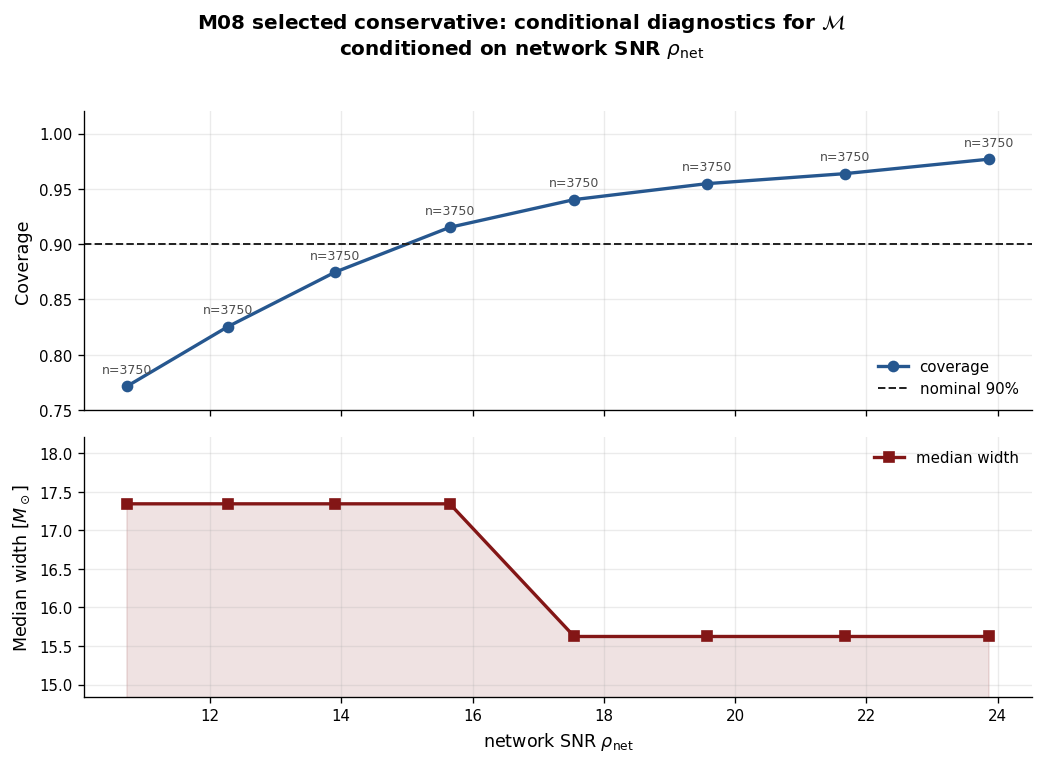

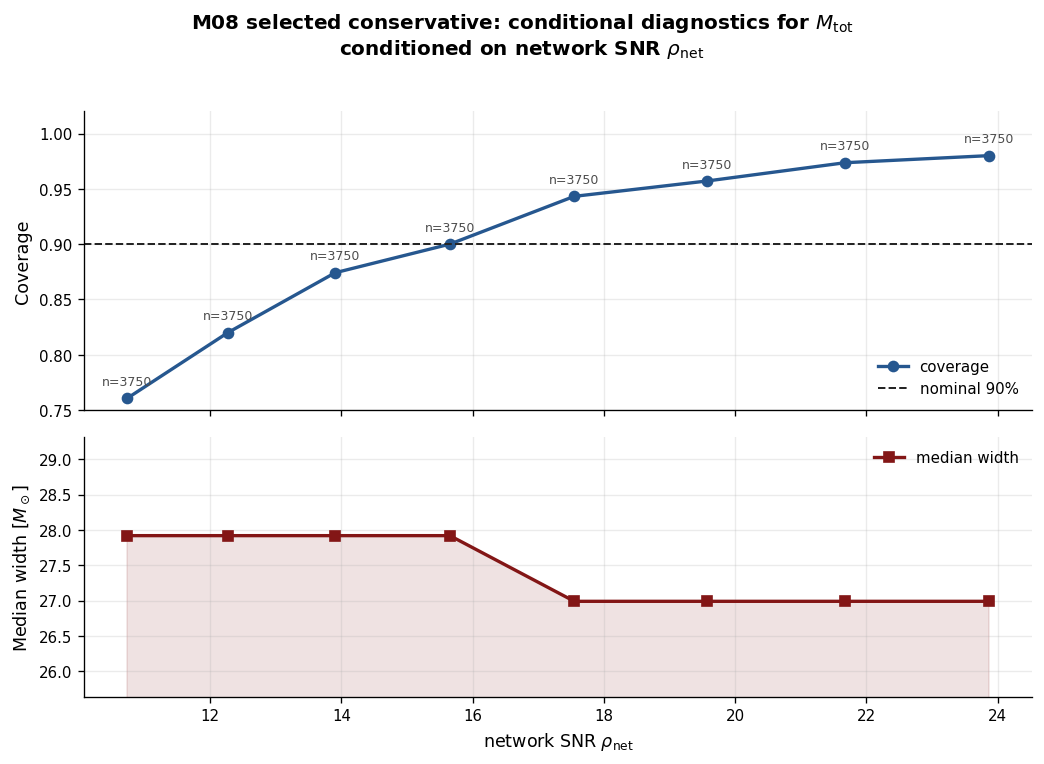

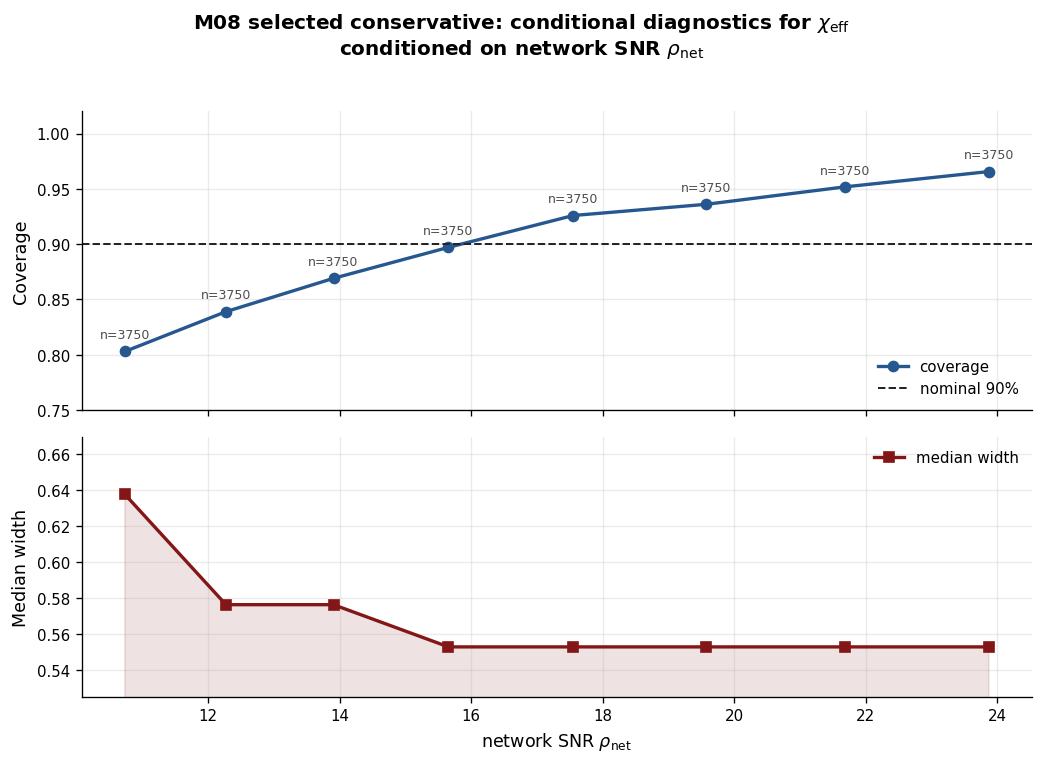

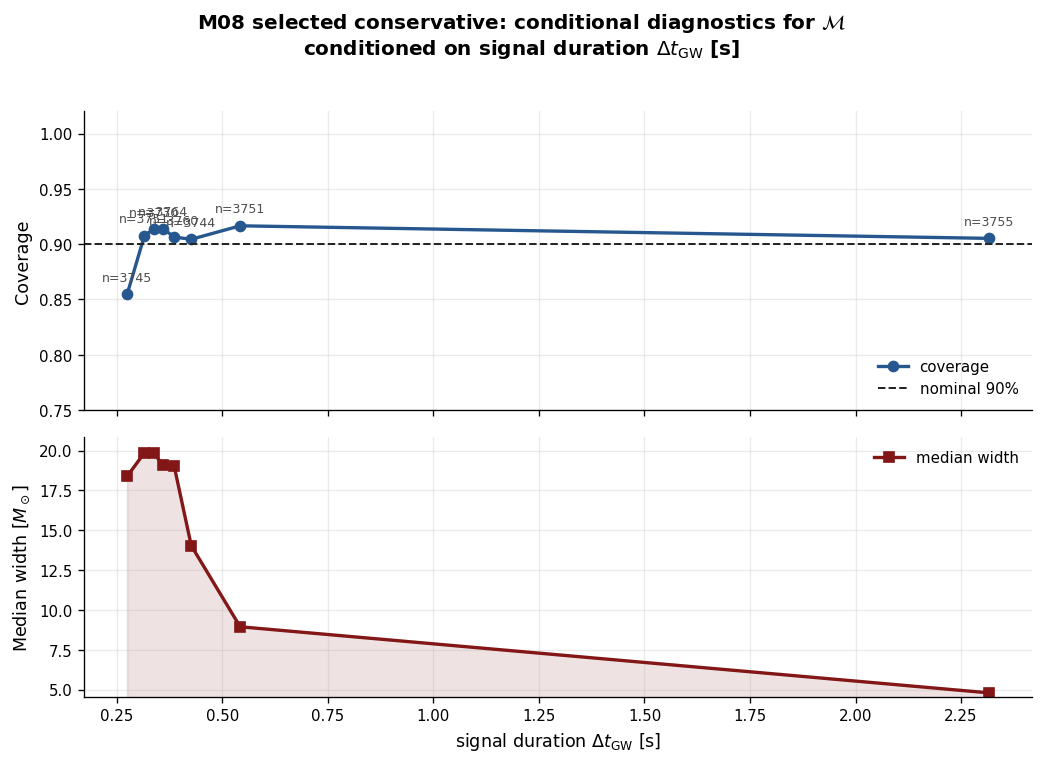

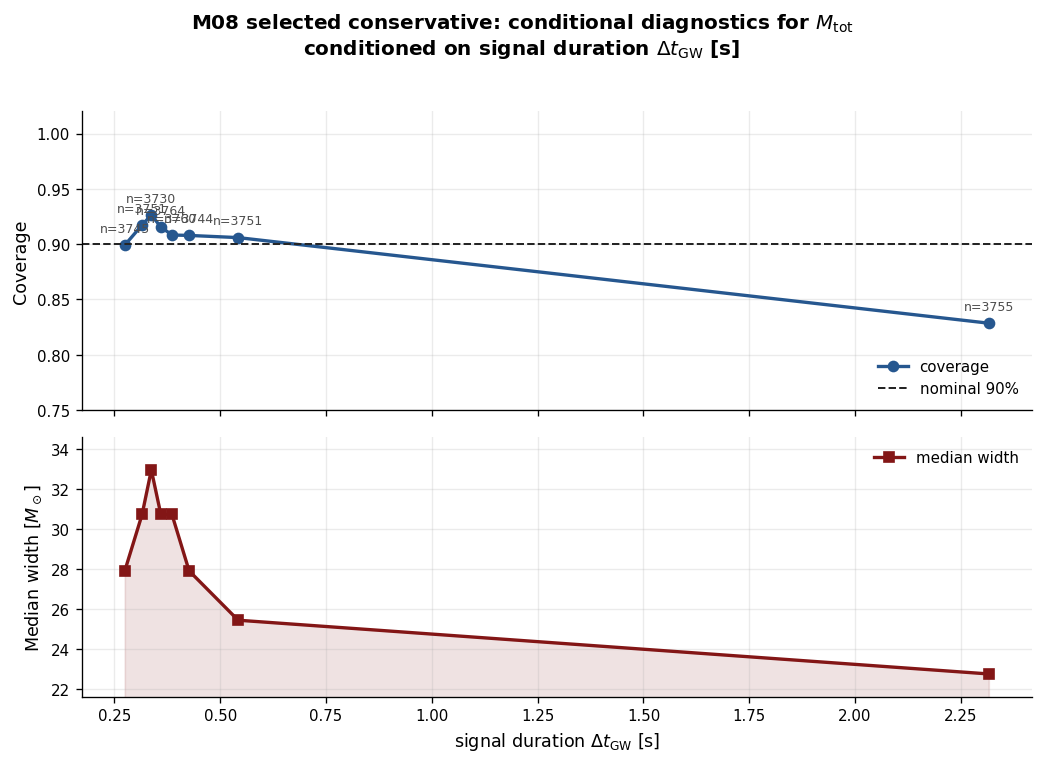

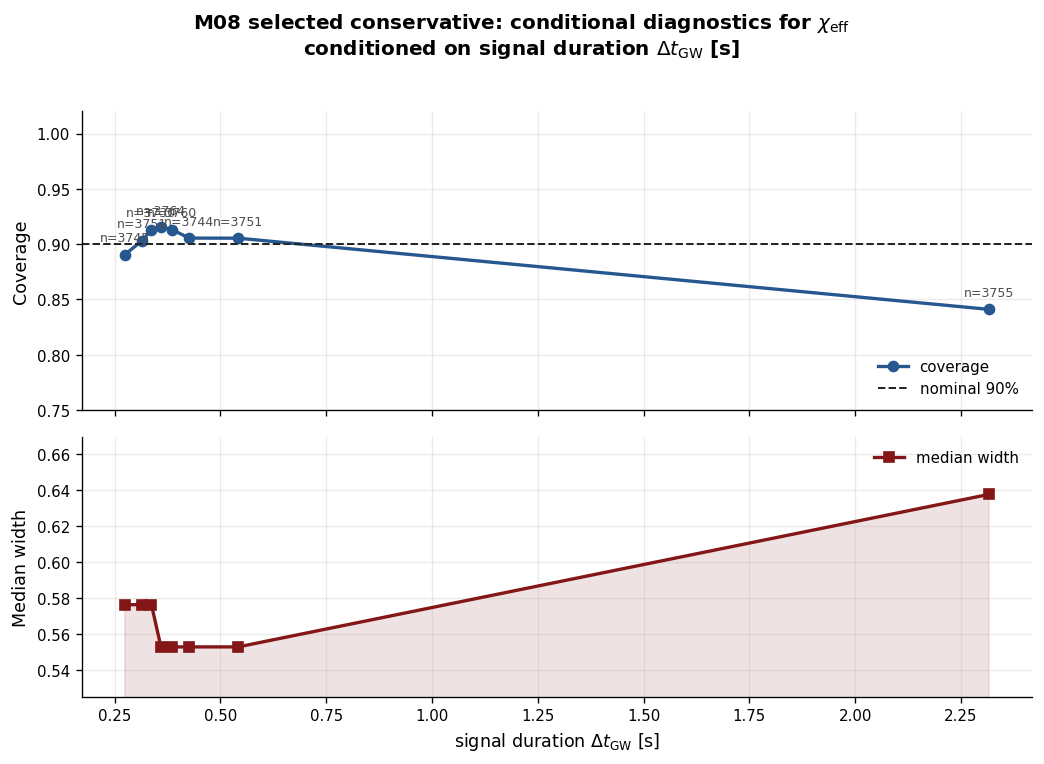

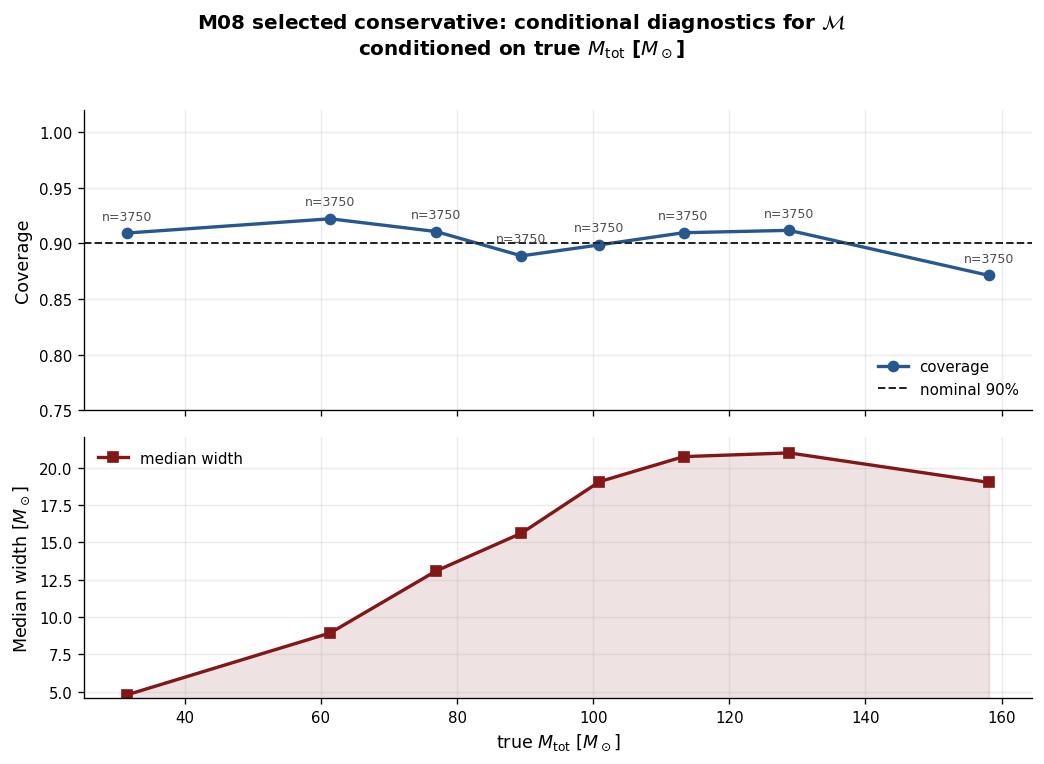

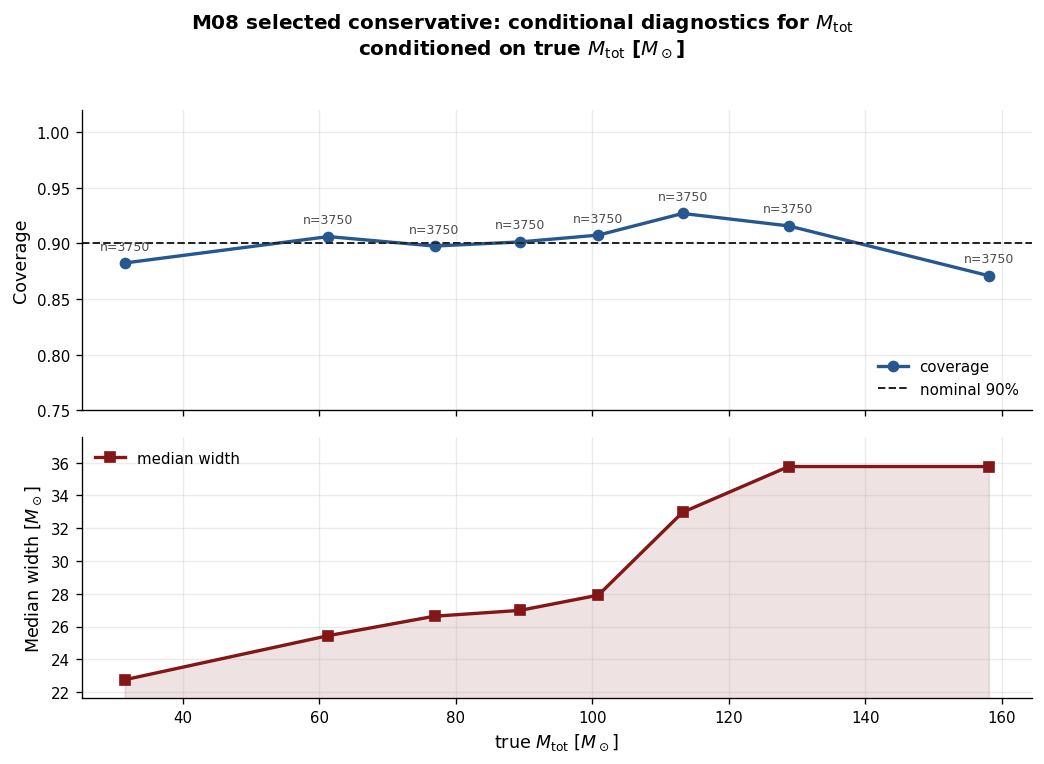

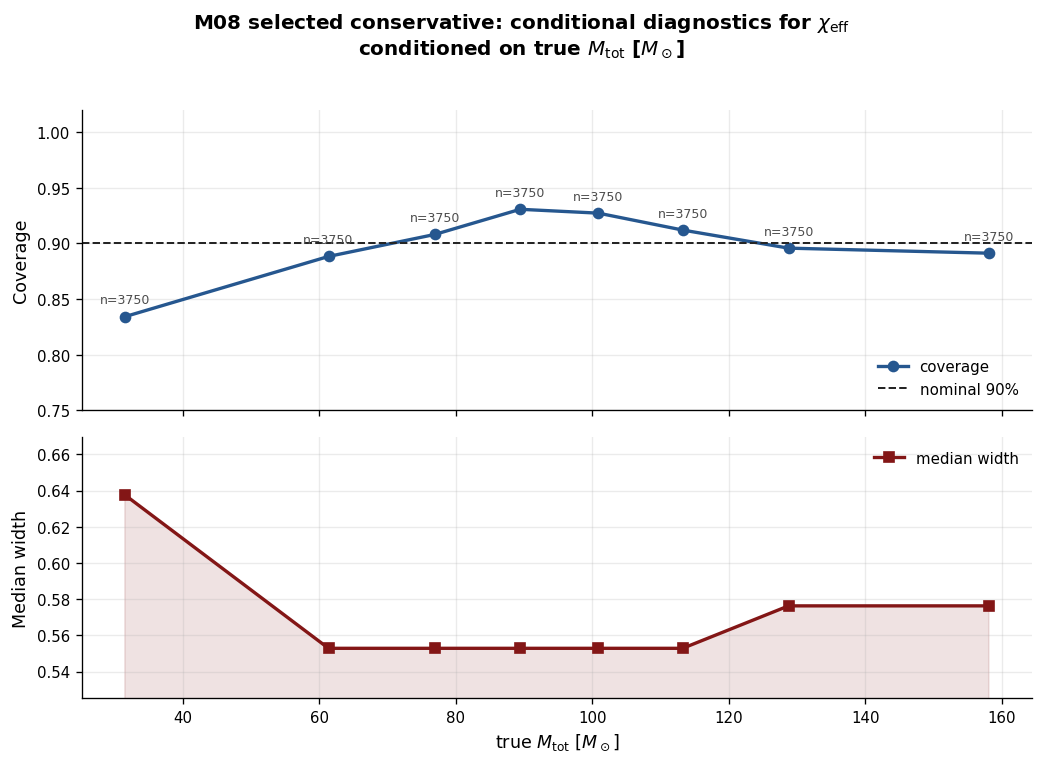

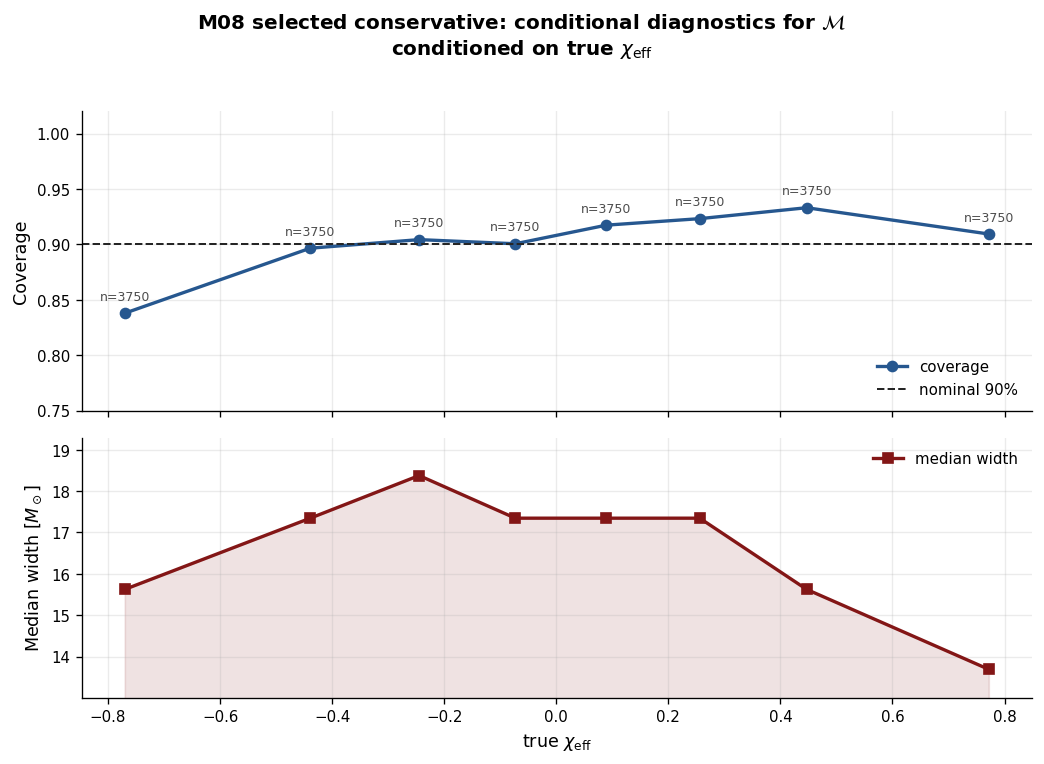

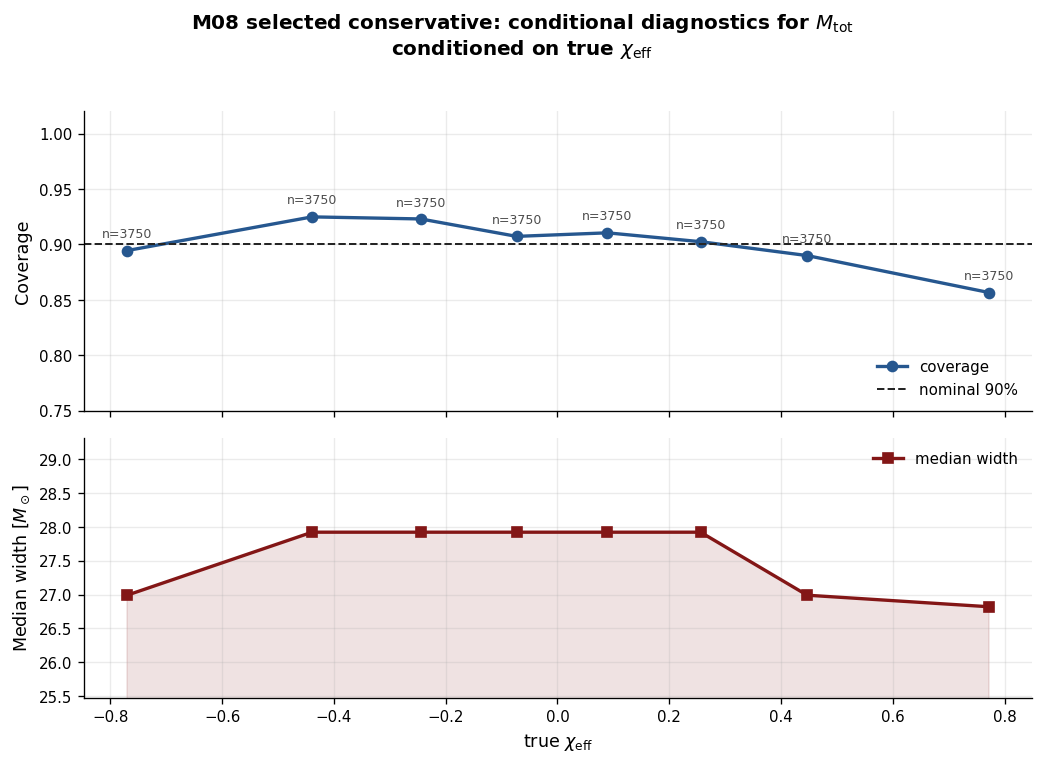

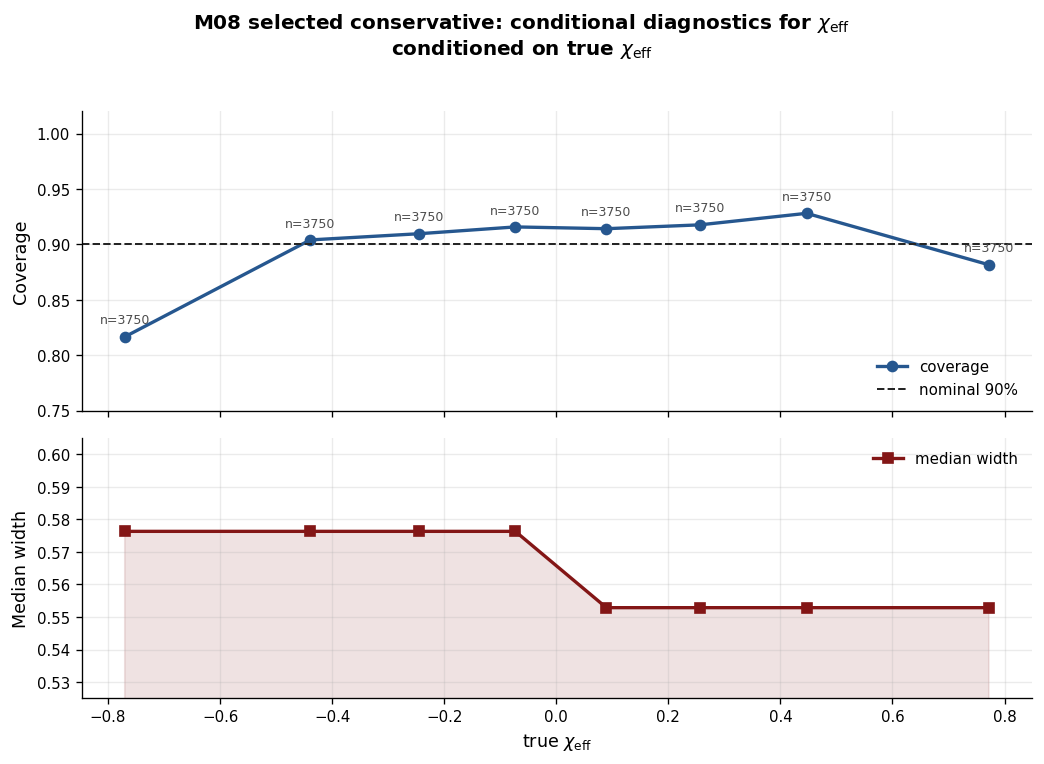

In [60]:
def plot_conditional_metrics(field="network_snr", final_policy="conservative"):
    for label in label_names:
        key = (final_policy, label, field)
        if key not in conditional_tables:
            print("Missing:", key)
            continue

        table = conditional_tables[key].copy()
        x = table["center"].values

        fig, (ax_cov, ax_width) = plt.subplots(
            2,
            1,
            figsize=(8.8, 6.2),
            sharex=True,
            gridspec_kw={"height_ratios": [1.15, 1.0]},
        )

        # Coverage panel
        ax_cov.plot(
            x,
            table["coverage"],
            marker="o",
            linewidth=2.0,
            color=PALETTE["coverage"],
            label="coverage",
        )
        ax_cov.axhline(
            CONFIDENCE_LEVEL,
            linestyle="--",
            linewidth=1.2,
            color=PALETTE["nominal"],
            label="nominal 90%",
        )
        ax_cov.set_ylabel("Coverage")
        ax_cov.set_ylim(0.75, 1.02)
        ax_cov.legend(loc="lower right")
        style_axis(ax_cov)

        for xi, cov, n in zip(x, table["coverage"], table["count"]):
            ax_cov.text(
                xi,
                min(1.005, cov + 0.012),
                f"n={int(n)}",
                fontsize=7.5,
                ha="center",
                color="0.30",
            )

        # Width panel
        ax_width.plot(
            x,
            table["median_width_phys"],
            marker="s",
            linewidth=2.0,
            color=PALETTE["width"],
            label="median width",
        )
        ax_width.fill_between(
            x,
            table["median_width_phys"],
            alpha=0.12,
            color=PALETTE["width"],
        )

        unit = label_unit(label)
        width_label = f"Median width [{unit}]" if unit else "Median width"
        ax_width.set_ylabel(width_label)
        ax_width.set_xlabel(table["conditioning_label"].iloc[0])
        ax_width.set_ylim(0.95 * min(table["median_width_phys"]), 1.05 * max(table["median_width_phys"]))
        ax_width.legend(loc="best")
        style_axis(ax_width)

        fig.suptitle(
            f"M08 selected {final_policy}: conditional diagnostics for {label_tex(label)}\n"
            f"conditioned on {table['conditioning_label'].iloc[0]}",
            y=1.02,
            fontsize=12,
            fontweight="semibold",
        )

        plt.tight_layout()
        plt.show()


for field in ["network_snr", "signal_network_duration", "total_mass", "chi_eff"]:
    if field in test_meta_df.columns:
        plot_conditional_metrics(field=field, final_policy="conservative")


## 13. Final selected systems

In [56]:
def summarize_selected_systems():
    rows = []

    for final_policy in ["conservative", "efficient"]:
        for label in label_names:
            label_idx = label_names.index(label)
            row, result = get_selected_result(label, final_policy=final_policy)

            widths_phys = (result.upper - result.lower)[:, label_idx] * y_std[label_idx]
            covered = (
                (result.lower[:, label_idx] <= y_test[:, label_idx])
                & (y_test[:, label_idx] <= result.upper[:, label_idx])
            )

            rows.append({
                "final_policy": final_policy,
                "label": label,
                "taxonomy_mode": row["taxonomy_mode"],
                "interval_mode": row["interval_mode"],
                "n_bins": int(row["n_bins"]),
                "coverage": float(covered.mean()),
                "median_width_phys": float(np.median(widths_phys)),
                "q90_width_phys": float(np.quantile(widths_phys, 0.90)),
                "q95_width_phys": float(np.quantile(widths_phys, 0.95)),
                "min_coverage_per_bin": row["min_coverage_per_bin"],
                "n_bins_under_2sigma": int(row["n_bins_under_2sigma"]),
                "max_undercoverage_gap": row["max_undercoverage_gap"],
                "tail_miss_imbalance": row["global_tail_miss_imbalance"],
            })

    return pd.DataFrame(rows)


selected_systems_df = summarize_selected_systems()
display(selected_systems_df)


,final_policy,label,taxonomy_mode,interval_mode,n_bins,coverage,median_width_phys,q90_width_phys,q95_width_phys,min_coverage_per_bin,n_bins_under_2sigma,max_undercoverage_gap,tail_miss_imbalance
0,conservative,chirp_mass,prediction,asymmetric,24,0.902767,15.623656,21.191378,21.730857,0.886381,0,0.013619,0.000233
1,conservative,total_mass,prediction,asymmetric,16,0.901067,27.919006,37.565449,38.805998,0.887652,0,0.012348,0.001933
2,conservative,chi_eff,difficulty,symmetric,6,0.898400,0.576291,0.812271,0.812271,0.892167,0,0.007833,0.002067
3,efficient,chirp_mass,difficulty,symmetric,24,0.901567,14.356512,23.366214,24.942036,0.873544,1,0.026456,0.002367
4,efficient,total_mass,prediction,asymmetric,32,0.901500,27.286712,37.805153,38.552800,0.874737,2,0.025263,0.001833
5,efficient,chi_eff,difficulty,symmetric,12,0.899067,0.561315,0.721185,0.894796,0.882232,1,0.017768,0.002133


### Compact report summary

In [57]:
def format_selected_systems_for_report(selected_systems_df):
    """
    Produce a compact text summary from selected_systems_df.
    Execute after selected_systems_df has been computed.
    """
    lines = []

    for policy in ["conservative", "efficient"]:
        sub = selected_systems_df[selected_systems_df["final_policy"] == policy]

        lines.append(f"\n{policy.upper()} SELECTED SYSTEMS")
        lines.append("-" * 80)

        for _, row in sub.iterrows():
            label = row["label"]
            unit = label_unit(label)

            width_unit = f" {unit}" if unit else ""

            lines.append(
                f"{label_tex(label)}: "
                f"{row['taxonomy_mode']} / {row['interval_mode']} / "
                f"{int(row['n_bins'])} bins | "
                f"coverage={row['coverage']:.4f}, "
                f"median width={row['median_width_phys']:.4g}{width_unit}, "
                f"q95 width={row['q95_width_phys']:.4g}{width_unit}, "
                f"min bin coverage={row['min_coverage_per_bin']:.4f}, "
                f"under-2σ bins={int(row['n_bins_under_2sigma'])}"
            )

    return "\n".join(lines)


print(format_selected_systems_for_report(selected_systems_df))



CONSERVATIVE SELECTED SYSTEMS
--------------------------------------------------------------------------------
$\mathcal{M}$: prediction / asymmetric / 24 bins | coverage=0.9028, median width=15.62 $M_\odot$, q95 width=21.73 $M_\odot$, min bin coverage=0.8864, under-2σ bins=0
$M_{\mathrm{tot}}$: prediction / asymmetric / 16 bins | coverage=0.9011, median width=27.92 $M_\odot$, q95 width=38.81 $M_\odot$, min bin coverage=0.8877, under-2σ bins=0
$\chi_{\mathrm{eff}}$: difficulty / symmetric / 6 bins | coverage=0.8984, median width=0.5763, q95 width=0.8123, min bin coverage=0.8922, under-2σ bins=0

EFFICIENT SELECTED SYSTEMS
--------------------------------------------------------------------------------
$\mathcal{M}$: difficulty / symmetric / 24 bins | coverage=0.9016, median width=14.36 $M_\odot$, q95 width=24.94 $M_\odot$, min bin coverage=0.8735, under-2σ bins=1
$M_{\mathrm{tot}}$: prediction / asymmetric / 32 bins | coverage=0.9015, median width=27.29 $M_\odot$, q95 width=38.55 $M_\

## 14. Save tables

In [58]:
OUTPUT_DIR = RESULTS_ROOT / "mondrian_M08_final_baseline"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

tables = {
    "point_metrics.csv": point_metrics_df,
    "global_point_metrics.csv": global_point_metrics_df,
    "global_conformal.csv": global_conformal_df,
    "mondrian_summary_all.csv": summary_df,
    "grid_aggregate_summary.csv": grid_agg_df,
    "selected_configurations.csv": selection_df,
    "top_candidates.csv": top_candidates_df,
    "selected_systems_summary.csv": selected_systems_df,
    "test_metadata.csv": test_meta_df,
    "conditional_metrics.csv": conditional_metrics_df,
}

for filename, dataframe in tables.items():
    path = OUTPUT_DIR / filename
    dataframe.to_csv(path, index=False)
    print("Saved:", path)

try:
    report_text = format_selected_systems_for_report(selected_systems_df)
    report_path = OUTPUT_DIR / "selected_systems_report.txt"
    report_path.write_text(report_text, encoding="utf-8")
    print("Saved:", report_path)
except Exception as exc:
    print("Report text not saved:", type(exc).__name__, exc)


Saved: /data/vserrano/cbc_pe_data/results/mondrian_M08_final_baseline/point_metrics.csv
Saved: /data/vserrano/cbc_pe_data/results/mondrian_M08_final_baseline/global_point_metrics.csv
Saved: /data/vserrano/cbc_pe_data/results/mondrian_M08_final_baseline/global_conformal.csv
Saved: /data/vserrano/cbc_pe_data/results/mondrian_M08_final_baseline/mondrian_summary_all.csv
Saved: /data/vserrano/cbc_pe_data/results/mondrian_M08_final_baseline/grid_aggregate_summary.csv
Saved: /data/vserrano/cbc_pe_data/results/mondrian_M08_final_baseline/selected_configurations.csv
Saved: /data/vserrano/cbc_pe_data/results/mondrian_M08_final_baseline/top_candidates.csv
Saved: /data/vserrano/cbc_pe_data/results/mondrian_M08_final_baseline/selected_systems_summary.csv
Saved: /data/vserrano/cbc_pe_data/results/mondrian_M08_final_baseline/test_metadata.csv
Saved: /data/vserrano/cbc_pe_data/results/mondrian_M08_final_baseline/conditional_metrics.csv
Saved: /data/vserrano/cbc_pe_data/results/mondrian_M08_final_basel

## 15. Final discussion and decision

### Baseline decision

M08 is adopted as the final operational baseline for the conformal/Mondrian analysis.

This decision is based on the full architecture comparison carried out before this notebook:

- M08 substantially improves the point-estimation error relative to the original M00 baseline.
- M09, which replaces the global average pooling with multi-window attention pooling, gives only a small additional improvement and does not clearly justify replacing M08.
- The attention-window analysis is useful as an interpretability diagnostic, but not as a sufficient reason to adopt M09 as a new baseline.

Therefore, the conformal analysis is frozen around:

```text
Model:      M08 / SimpleCNN_ResidualDilated
Seed:       123
Dataset:    500k BBH processed HDF5
Targets:    chirp_mass, total_mass, chi_eff
Calibration: split conformal + Mondrian conformal
```

### What the point-estimation diagnostics show

The true-vs-predicted and residual-density plots are important because they show the main remaining limitation of the point estimator.

The model performs well in the dense central region of the training distribution, but the residual-density plots reveal regression-to-the-mean behavior in the tails:

- low true masses tend to be overestimated;
- high true masses tend to be underestimated;
- extreme $\chi_{\mathrm{eff}}$ values are compressed toward the central region.

This is not primarily a conformal-calibration problem. Conformal intervals can restore coverage, but they do not remove bias from the point predictor. If the predictor is biased in the tails, conformal intervals tend to become wider or locally less efficient in those regions.

### Why Mondrian conformal is still useful

The global split-conformal baseline gives one residual scale per target. This is valid as a broad reference, but it ignores the fact that the residual distribution changes across prediction regions, difficulty regimes, SNR, and physical parameter values.

Mondrian conformal calibration is used to adapt the interval width locally. The final selected configurations should therefore be reported per target rather than as a single universal setting.

The final compact result is `selected_systems_df`. For each target, report:

- taxonomy mode;
- interval mode;
- number of bins;
- global coverage;
- median physical interval width;
- q90/q95 physical width;
- minimum bin coverage;
- number of bins below the two-sigma lower tolerance;
- maximum undercoverage gap;
- tail-miss imbalance.

### Conditional diagnostics

The conditional diagnostics are not used to fit the intervals. They are a stress test of the selected systems.

They answer questions such as:

- does coverage remain close to 90% at low SNR?
- do intervals become wider for long or difficult signals?
- do high-mass or extreme-spin regions show local undercoverage?
- is the selected Mondrian taxonomy actually controlling the regions where the point model is biased?

These plots should be used in the discussion section to avoid overclaiming purely global coverage.

### Recommended report wording

```text
M08 is adopted as the final baseline for the conformal analysis. The selected
Mondrian configurations achieve empirical coverage close to the nominal 90%
level while providing target-dependent interval widths. The chosen configurations
differ across chirp mass, total mass, and effective spin, reflecting the
different residual structures of the three regression targets.

The conditional diagnostics show that global coverage alone is not sufficient:
coverage and interval width vary across SNR, signal duration, and regions of the
physical parameter space. Mondrian calibration partially adapts to this
heterogeneity, but the residual-density plots show that the dominant remaining
limitation is regression to the mean in the point estimator, especially in the
tails of the mass and effective-spin distributions.
```

### Next step

Do not continue with small architecture variants at this stage.

The next separate analysis should focus specifically on regression to the mean in the point estimator. Reasonable candidates are:

1. weighted MSE or tail-aware losses;
2. SmoothL1/Huber losses compared against MSE;
3. loss terms that penalize slope contraction;
4. target transformations;
5. sampling or reweighting by physical parameter bins;
6. post-hoc linear or isotonic recalibration;
7. checking whether any correction improves slope and tail bias without degrading conformal validity.

This should be treated as a new modelling notebook/thread, not mixed into the final Mondrian baseline notebook.
